In [91]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns 

In [92]:
systems_cleaned = pd.read_csv('../../../data/core/systems_cleaned.csv')
systems_cleaned.columns

Index(['system_id', 'system_public_name', 'site_location',
       'timezone_or_utc_offset', 'latitude', 'longitude', 'elevation_m',
       'dc_capacity_kW', 'kg_climate', 'pvcz_composite', 'pvcz_t_rack',
       'pvcz_t_roof', 'pvcz_humidity', 'pvcz_wind', 'tracking', 'type',
       'azimuth', 'tilt', 'first_timestamp', 'last_timestamp', 'years',
       'number_records', 'dataset_size_mb', 'available_sensor_channels',
       'qa_status', 'qa_issue', 'first_year', 'is_prize_data',
       'is_lake_parquet_data', 'is_lake_csv_data', 'has_irradiance_data',
       'has_ambient_temperature_data', 'has_temperature_data',
       'has_power_data', 'has_current_data', 'has_voltage_data', 'has_ac_data',
       'has_dc_data', 'module_type', 'simplified_type', 'system_source'],
      dtype='str')

In [93]:
metrics_dir = Path("../../../data/raw/parquet-metrics/")
metrics_pq = pq.ParquetDataset(metrics_dir)
metrics_df = metrics_pq.read().to_pandas()
metrics_id_set = set(metrics_df.system_id)

# Early Ideas

In [94]:
system_id = 1200
relevant_rows_systems = systems_cleaned[systems_cleaned['system_id'] == system_id]
for j in relevant_rows_systems.index[0:1]:
    max_dc_capacity = relevant_rows_systems.loc[j, 'dc_capacity_kW']
    system_type = relevant_rows_systems.loc[j, 'simplified_type']
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]

In [95]:
relevant_rows_systems

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_ambient_temperature_data,has_temperature_data,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type,system_source
11,1200,Distributed Sun - BWI Hilton,"Linthicum Heights, MD",America/New_York,39.1958,-76.6808,155.0,51.84,Cfa,34,...,True,True,True,True,True,True,True,mono-Si,monocrystalline_Si,PVDAQ General


In [96]:
relevant_rows_metrics

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
51,1200,2751,ac_power,AC power,W,W,1.000000,0.000000,ac_power_metered_kW,avg,NaN,NaN,,ac_power__2751
52,1200,2752,dc_power,DC power,W,W,1.000000,0.000000,,avg,NaN,NaN,,dc_power__2752
53,1200,2757,inv1_ac_power,AC power,W,W,1.000000,0.000000,,avg,NaN,NaN,,inv1_ac_power__2757
54,1200,2758,inv1_dc_power,DC power,W,W,1.000000,0.000000,,avg,NaN,NaN,,inv1_dc_power__2758
55,1200,2762,inv2_ac_power,AC power,W,W,1.000000,0.000000,,avg,NaN,NaN,,inv2_ac_power__2762
56,1200,2763,inv2_dc_power,DC power,W,W,1.000000,0.000000,,avg,NaN,NaN,,inv2_dc_power__2763
57,1200,2767,inv3_ac_power,AC power,W,W,1.000000,0.000000,,avg,NaN,NaN,,inv3_ac_power__2767
58,1200,2768,inv3_dc_power,DC power,W,W,1.000000,0.000000,,avg,NaN,NaN,,inv3_dc_power__2768
59,1200,2772,inv4_ac_power,AC power,W,W,1.000000,0.000000,,avg,NaN,NaN,,inv4_ac_power__2772
60,1200,2773,inv4_dc_power,DC power,W,W,1.000000,0.000000,,avg,NaN,NaN,,inv4_dc_power__2773


## First search for metrics with fragments in the name

In [97]:
def metrics_search_for_fragment_df(df: pd.DataFrame, fragment: str):
    fragment = fragment.lower()
    return df[
        (df.loc[:, 'sensor_name'].str.contains(fragment, case=False))
        | (df.loc[:, 'common_name'].str.contains(fragment, case=False))
    ]

In [98]:
def metrics_search_for_two_fragments_df(df: pd.DataFrame, fragment_1: str,
                                        fragment_2: str, and_or: str):
    fragment_1 = fragment_1.lower()
    fragment_2 = fragment_2.lower()
    if and_or == 'and':
        return df[
            ((df.loc[:, 'sensor_name'].str.contains(fragment_1, case=False))
             | (df.loc[:, 'common_name'].str.contains(fragment_1, case=False)))
            & ((df.loc[:, 'sensor_name'].str.contains(fragment_2, case=False))
             | (df.loc[:, 'common_name'].str.contains(fragment_2, case=False)))
        ]
    elif and_or == 'or':
        return df[
            ((df.loc[:, 'sensor_name'].str.contains(fragment_1, case=False))
             | (df.loc[:, 'common_name'].str.contains(fragment_1, case=False)))
            | ((df.loc[:, 'sensor_name'].str.contains(fragment_2, case=False))
             | (df.loc[:, 'common_name'].str.contains(fragment_2, case=False)))
        ]

In [99]:
# sample use -- search for ac and power
system_id = 1420
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1165,1420,4812,ac_power_KwAC,AC power,W,W,1000.0,0.0,,avg,NaN,NaN,AE_HID=37939,ac_power_kwac__4812


Justify the inclusion of 'W_avg', 'RTW' in ac sensor names!

In [101]:
# show nothing but AC power
assert(set(metrics_df[metrics_df['sensor_name'] == 'W_avg'].common_name) == {'AC power'})
assert(set(metrics_df[metrics_df['sensor_name'] == 'RTW'].common_name) == {'AC power'})

# Towards getting All AC_Power system names

## Initial Attempt

In [103]:
def find_all_aggregate_power_names_draft():
    '''Find all ac aggregator names.'''
    global metrics_df, systems_cleaned
    power_data = metrics_search_for_fragment_df(metrics_df, 'pow')
    ac_data = metrics_search_for_fragment_df(metrics_df, 'ac')
    power_ids = set(power_data.system_id).intersection(set(systems_cleaned.system_id),
                                                       set(ac_data.system_id))
    ac_pow_agg_dict = {
        system_id: [] for system_id in power_ids
    }
    ac_agg_sensor_names = ['ac_power', 'ac_power_hW', 'ac_power_kW', 'ac_power_1_6',
                           'InvPAC_kW_Avg', 'ac_power_calc', 'W_avg',
                           'ac_power_metered_kW', 'RTW',
                           'inv_total_ac_power', 'metered_ac_power',
                           'real_power_kW', 'ac_power_KwAC',
                           'ac_power_metered_1_2',
                           'PwrMtrP_kW_Avg']
    for sensor_name in ac_agg_sensor_names:
        exact_name_metrics = metrics_df[
                metrics_df['sensor_name'] == sensor_name
        ]
        for system_id in set(exact_name_metrics['system_id']).intersection(set(systems_cleaned.system_id)):
            relevant_rows_metrics = metrics_df[(metrics_df['system_id']==system_id)
                                               & (metrics_df['sensor_name']==sensor_name)]
            if len(relevant_rows_metrics.index) > 1:
                raise RuntimeError(f'System {system_id} has multiple sensors named {sensor_name}!')
            else:
                ind = relevant_rows_metrics.index[0]
                metric_id = relevant_rows_metrics.loc[ind, 'metric_id']
                common_name = relevant_rows_metrics.loc[ind, 'common_name']
                given_unit = relevant_rows_metrics.loc[ind, 'units']
                calc_type = relevant_rows_metrics.loc[ind, 'calc_details']
                ac_pow_agg_dict[system_id].append({
                    'metric_id': metric_id,
                    'sensor_name': sensor_name,
                    'common_name': common_name,
                    'units': given_unit,
                    'calc_details': calc_type,
                    'whole_or_part': 'whole'
                })
    # quick checks
    for system_id in power_ids:
        # check for missing entries
        if len(ac_pow_agg_dict[system_id]) == 0:
            print(f'System {system_id} appears to have no obvious AC power aggregator name.')
        # check for duplicates
        elif len(ac_pow_agg_dict[system_id]) != 1:
            print(f'System {system_id} has multiple AC power aggregators!')
            for term in ac_pow_agg_dict[system_id]:
                print(term)

    return ac_pow_agg_dict

In [104]:
ac_agg_names = find_all_aggregate_power_names_draft()

System 1200 has multiple AC power aggregators!
{'metric_id': np.int32(2751), 'sensor_name': 'ac_power', 'common_name': 'AC power', 'units': 'W', 'calc_details': 'ac_power_metered_kW', 'whole_or_part': 'whole'}
{'metric_id': np.int32(4197), 'sensor_name': 'ac_power_metered_kW', 'common_name': 'AC power', 'units': 'W', 'calc_details': '', 'whole_or_part': 'whole'}
System 1202 has multiple AC power aggregators!
{'metric_id': np.int32(2840), 'sensor_name': 'ac_power', 'common_name': 'AC power', 'units': 'W', 'calc_details': 'inv1_ac_power+inv2_ac_power+inv3_ac_power+inv4_ac_power+inv5_ac_power+inv6_ac_power', 'whole_or_part': 'whole'}
{'metric_id': np.int32(2802), 'sensor_name': 'ac_power_metered_kW', 'common_name': 'AC power', 'units': 'W', 'calc_details': '', 'whole_or_part': 'whole'}
System 1208 has multiple AC power aggregators!
{'metric_id': np.int32(1016), 'sensor_name': 'ac_power_metered_kW', 'common_name': 'AC power', 'units': 'W', 'calc_details': '', 'whole_or_part': 'whole'}
{'me

Notes on duplicates from experiments (testing area):

System 1200: `ac_power` is the AC power in Watts, `ac_power_metered_kW` is the AC power in kilowatts.  I only need one!

Rather annoyingly, `inv(blah)_ac_power` is only recorded to Dec 1st, 2013 (and roughly mid-minute) and `ac_power` is only recorded after Nov. 29, 2013 (and always on-the-minute).  Thus, we really have two separate data-sets here!

System 1202:  `ac_power` is the Inverter power sum, and `ac_power_metered_kW` is the Meter power total.

These are not so near-disjoint, but they are only loosely dependent at times for which they are both recorded.

System 1283: `ac_power` and `ac_power_metered_kW` are distinct, despite their seeming to come from the same meter data.  (The sum of the inverter powers is different still!)

System 1332: `inv_total_ac_power` (the sum of the inverter totals) and `metered_ac_power` are largely collinear, but not completely.  Both are well-behaved, but `metered_ac_power` has less missingness.

Systems 4901-4903 are very rich-data systems, so it is unsurprising that they have both inverter and meter totals.

In [105]:
my_units = []
for system_id in ac_agg_names.keys():
    for metric_dict in ac_agg_names[system_id]:
        my_units.append(metric_dict['units'])
my_units = set(my_units)
my_units


{'W', 'kW'}

No missing units in AC case (so far) -- Yay!

Widen search to `calc_details` and `source_type` to try to discern which things are inverter, meter, etc.

In [106]:
def widened_search_for_fragment_df(df: pd.DataFrame, fragment: str):
    fragment = fragment.lower()
    return df[
        (df.loc[:, 'sensor_name'].str.contains(fragment, case=False))
        | (df.loc[:, 'common_name'].str.contains(fragment, case=False))
        | (df.loc[:, 'calc_details'].str.contains(fragment, case=False))
        | (df.loc[:, 'source_type'].str.contains(fragment, case=False))
    ]

In [107]:
def widened_search_for_two_fragments_df(df: pd.DataFrame, fragment_1: str,
                                        fragment_2: str, and_or: str):
    fragment_1 = fragment_1.lower()
    fragment_2 = fragment_2.lower()
    if and_or == 'and':
        return df[
            ((df.loc[:, 'sensor_name'].str.contains(fragment_1, case=False))
             | (df.loc[:, 'common_name'].str.contains(fragment_1, case=False))
             | (df.loc[:, 'calc_details'].str.contains(fragment_1, case=False))
             | (df.loc[:, 'source_type'].str.contains(fragment_1, case=False)))
            & ((df.loc[:, 'sensor_name'].str.contains(fragment_2, case=False))
             | (df.loc[:, 'common_name'].str.contains(fragment_2, case=False))
             | (df.loc[:, 'calc_details'].str.contains(fragment_2, case=False))
             | (df.loc[:, 'source_type'].str.contains(fragment_2, case=False)))
        ]
    elif and_or == 'or':
        return df[
            ((df.loc[:, 'sensor_name'].str.contains(fragment_1, case=False))
             | (df.loc[:, 'common_name'].str.contains(fragment_1, case=False))
             | (df.loc[:, 'calc_details'].str.contains(fragment_1, case=False))
             | (df.loc[:, 'source_type'].str.contains(fragment_1, case=False)))
            | ((df.loc[:, 'sensor_name'].str.contains(fragment_2, case=False))
             | (df.loc[:, 'common_name'].str.contains(fragment_2, case=False))
             | (df.loc[:, 'calc_details'].str.contains(fragment_2, case=False))
             | (df.loc[:, 'source_type'].str.contains(fragment_2, case=False)))
        ]

In [108]:
power_data = metrics_search_for_fragment_df(metrics_df, 'pow')

In [109]:
widened_search_for_two_fragments_df(power_data, 'ac', 'met', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
51,1200,2751,ac_power,AC power,W,W,1.0,0.0,ac_power_metered_kW,avg,NaN,NaN,,ac_power__2751
71,1200,4197,ac_power_metered_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_power_metered_kw__4197
124,1202,2802,ac_power_metered_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_power_metered_kw__2802
143,1203,2889,ac_power,AC power,W,W,1.0,0.0,ac_meter_1_power_kW+ac_meter_2_power_kW,avg,NaN,NaN,,ac_power__2889
152,1203,2909,ac_meter_1_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_meter_1_power_kw__2909
153,1203,2910,ac_meter_2_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_meter_2_power_kw__2910
227,1208,1133,ac_power_metered_1_2,AC power,W,W,1.0,0.0,ac_meter_1_power_kW+ac_meter_2_power_kW,avg,NaN,NaN,,ac_power_metered_1_2__1133
230,1208,1016,ac_power_metered_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_power_metered_kw__1016
231,1208,1017,ac_meter_1_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_meter_1_power_kw__1017
232,1208,1018,ac_meter_2_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_meter_2_power_kw__1018


Revised step one with inverter/meter/unknown data (and metadata improvements)

In [110]:
# Feel free to adjust these naming conventions for your variable.

def ac_pow_metadata_name(source_type: str):
    '''Give the name to put in the metadata table.'''
    if source_type is not None:
        return f'has_ac_power_{source_type}_aggregate'
    else:
        return f'has_ac_power_aggregate'


In [141]:
def find_all_aggregate_power_names(
    systems_cleaned: pd.DataFrame,
    metrics_df: pd.DataFrame,
    ac_agg_sensor_names,
    print_warnings: bool = False,
    known_sources = ('inverter', 'meter'),
    known_sources_short = ('inv', 'met')
):
    '''Find all ac aggregator names per-system,
    given a list of aggregate sensor names.
    
    Parameters
    ----------
    systems_cleaned: pandas.DataFrame
        The data from data/core/systems_cleaned.csv
    metrics_df: pandas.DataFrame
        The data from data/raw/parquet-metrics/
    ac_agg_sensor_names: iterable of strings
        An iterable containing the names to search for
    print_warnings: bool
        Print warnings about too few or too many aggregators.
    known_sources: iterable of strings
        Full names of the known source types.
    known_shources_short: iterable of strings
        fragments of the known source names suitable for searching

    Returns
    --------
    ac_pow_agg_dict: dict[list[dict]]
        A dictionary, indexed by relevant system_id's.
        The value of ac_pow_agg_dict[system_id] is a list of dictionaries,
        one for each aggregator metric for the systems_id.  Keys for each metric are:
            "metric_id" -- the metric_id number
            "sensor_name" -- the sensor_name term
            "common_name" -- the common-name term
            "units" -- the units for each term
            "whole_or_part" -- determining whether each term is aggregate or a sub-part
            always "whole" for now, but we will add sub-parts in the next function
            "source_type": the source type if known, or "unknown" if unknown
    ac_pow_metadata_df: pandas.DataFrame
        If sources_matter = True, then a DataFrame indicating both
        which systems have aggregate variable data, and the aggregate data
        per subtype
        If sources_matter = False, a DataFrame indicating which systems have 
        aggregate variable data only. 
    '''

    # sanitize known_sources and known_sources_short input
    if len(known_sources) != len(known_sources_short):
        raise ValueError('Incorrect match between names and fragments\n'
                         + 'of known_sources and known_sources_short:\n'
                         + f'{len(known_sources)} vs. {len(known_sources_short)}')
    elif 'unknown' not in known_sources:
        # add 'unknown' category to catch all remaining terms
        # and lowercase everything
        known_sources = [
            source_type.lower() for source_type in known_sources
        ]
        known_sources.append('unknown')
        known_sources_short = [
            source_fragment.lower()
            for source_fragment in known_sources_short
        ]
        known_sources_short.append('')  # unknown is a catch-all

    # get data-holders initialized
    ac_power_data = metrics_search_for_two_fragments_df(metrics_df, 'ac', 'pow', 'and')
    power_ids = set(ac_power_data.system_id).intersection(set(systems_cleaned.system_id))
    ac_pow_agg_dict = {
        system_id: [] for system_id in power_ids
    }
    num_ids = len(power_ids)
    col_names = [ac_pow_metadata_name(None),]
    for source_type in known_sources:
        col_names.append(ac_pow_metadata_name(source_type))
    num_cols = len(col_names)
    ac_pow_metadata_df = pd.DataFrame(
        np.full(shape=(num_ids, num_cols), fill_value=False, dtype='bool'),
        index=ac_pow_agg_dict.keys(),
        columns=col_names
    )
    ac_pow_metadata_df = ac_pow_metadata_df.sort_index()

    for sensor_name in ac_agg_sensor_names:
        exact_name_metrics = metrics_df[
                metrics_df['sensor_name'] == sensor_name
        ]
        for system_id in set(exact_name_metrics['system_id']).intersection(set(systems_cleaned.system_id)):
            relevant_rows_metrics = exact_name_metrics[exact_name_metrics['system_id']==system_id]
            if len(relevant_rows_metrics.index) > 1:
                raise RuntimeError(f'System {system_id} has multiple sensors named {sensor_name}!')
            else:
                ac_pow_metadata_df.loc[system_id, ac_pow_metadata_name(None)] = True
                ind = relevant_rows_metrics.index[0]
                metric_id = relevant_rows_metrics.loc[ind, 'metric_id']
                common_name = relevant_rows_metrics.loc[ind, 'common_name']
                given_unit = relevant_rows_metrics.loc[ind, 'units']
                # correct a typo
                if (system_id == 1200) and (sensor_name == 'ac_power_metered_kW'):
                    given_unit = 'kW'
                calc_type = relevant_rows_metrics.loc[ind, 'calc_details']
                raw_source_type = relevant_rows_metrics.loc[ind, 'source_type']
                if raw_source_type is np.nan:
                    raw_source_type = 'unknown'
                # find inverter-aggregator modules
                for j in range(len(known_sources_short)):
                    source_type = known_sources[j]
                    source_fragment = known_sources_short[j]
                    if (source_fragment in sensor_name.lower())\
                      or (source_fragment in common_name.lower())\
                      or (source_fragment in calc_type.lower())\
                      or (source_fragment in raw_source_type.lower()):
                        ac_pow_agg_dict[system_id].append({
                            'metric_id': metric_id,
                            'sensor_name': sensor_name,
                            'common_name': common_name,
                            'units': given_unit,
                            'calc_details': calc_type,
                            'whole_or_part': 'whole',
                            'source_type': source_type,
                        })
                        ac_pow_metadata_df.loc[system_id, ac_pow_metadata_name(source_type)] = True
                        # for each particular system_id/sensor_name pair,
                        # only one type, so as soon as a match,
                        break 
    # quick checks
    if print_warnings:
        for system_id in power_ids:
            # check for missing entries
            if len(ac_pow_agg_dict[system_id]) == 0:
                print(f'System {system_id} appears to have no obvious AC power aggregator name.')
            # check for duplicates
            elif (len(ac_pow_agg_dict[system_id]) != 1):
                # only a problem if multiples per system_id
                source_type_counts = {
                    source_type: 0 for source_type in known_sources
                }
                for metric_dict in ac_pow_agg_dict[system_id]:
                    source_type_counts[metric_dict['source_type']] += 1
                for source_type in source_type_counts:
                    if source_type_counts[source_type] > 1:
                        print(f'System {system_id} has multiple ac_power '
                              + f'aggregators from the {source_type} source:')
                        for metric_dict in ac_pow_agg_dict[system_id]:
                            print(metric_dict)

    return (ac_pow_agg_dict, ac_pow_metadata_df)

In [ ]:
ac_agg_sensor_names = ('ac_power', 'ac_power_hW', 'ac_power_kW', 'ac_power_1_6',
                        'InvPAC_kW_Avg', 'ac_power_calc', 'W_avg',
                       'ac_power_metered_kW', 'RTW',
                       'inv_total_ac_power', 'metered_ac_power',
                       'real_power_kW', 'ac_power_KwAC',
                       'ac_power_metered_1_2',
                       'PwrMtrP_kW_Avg')
agg_names_rev, agg_metadata = find_all_aggregate_power_names(systems_cleaned=systems_cleaned,
                                                             metrics_df=metrics_df,
                                                             ac_agg_sensor_names=ac_agg_sensor_names,
                                                             print_warnings=True)

System 1200 has multiple ac_power aggregators from the meter source:
{'metric_id': np.int32(2751), 'sensor_name': 'ac_power', 'common_name': 'AC power', 'units': 'W', 'calc_details': 'ac_power_metered_kW', 'whole_or_part': 'whole', 'source_type': 'meter'}
{'metric_id': np.int32(4197), 'sensor_name': 'ac_power_metered_kW', 'common_name': 'AC power', 'units': 'kW', 'calc_details': '', 'whole_or_part': 'whole', 'source_type': 'meter'}
System 1208 has multiple ac_power aggregators from the meter source:
{'metric_id': np.int32(1016), 'sensor_name': 'ac_power_metered_kW', 'common_name': 'AC power', 'units': 'W', 'calc_details': '', 'whole_or_part': 'whole', 'source_type': 'meter'}
{'metric_id': np.int32(1133), 'sensor_name': 'ac_power_metered_1_2', 'common_name': 'AC power', 'units': 'W', 'calc_details': 'ac_meter_1_power_kW+ac_meter_2_power_kW', 'whole_or_part': 'whole', 'source_type': 'meter'}
System 1283 has multiple ac_power aggregators from the meter source:
{'metric_id': np.int32(1137)

In [113]:
agg_metadata

,has_ac_power_aggregate,has_ac_power_inverter_aggregate,has_ac_power_meter_aggregate,has_ac_power_unknown_aggregate
4,True,False,False,True
10,True,False,False,True
33,True,False,False,True
34,True,False,False,True
35,True,False,False,True
...,...,...,...,...
1432,True,False,False,True
1433,True,False,False,True
4901,True,True,True,False
4902,True,True,True,False


## Clarify units and power-factors before continuing

In [114]:
power_data = metrics_search_for_fragment_df(metrics_df, 'pow')
power_data[(power_data['common_name'].str.contains('ac', case=False))
           & ~(power_data['units'].isin(['W', 'kW']))]

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
88,1200,4198,power_factor,AC other,-,-,1.000,0.0,,NaN,NaN,NaN,,power_factor__4198
94,1201,2799,power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,power_factor__2799
141,1202,2805,power_factor,AC other,-,-,1.000,0.0,,NaN,NaN,NaN,,power_factor__2805
154,1203,2901,inv1_power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,inv1_power_factor__2901
155,1203,2908,inv2_power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,inv2_power_factor__2908
449,1276,3038,power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,power_factor__3038
464,1277,3053,power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,power_factor__3053
484,1278,3068,inv1_power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,inv1_power_factor__3068
485,1278,3077,inv2_power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,inv2_power_factor__3077
526,1284,957,power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,power_factor__957


Thus, all power-terms not in W or kW are energy terms (kWh et c.), power-factors, and other components of complex power (the kVA and kVAR terms)  Not relevant for this part!

## Second Run -- Grab all AC power, non-power-factor terms.  

### Helper Functions

In [115]:
def ac_pow_metadata_part_name(source_type: str):
    '''Give the name to put in the metadata table.'''
    if source_type is not None:
        return f'has_ac_power_{source_type}_subsystems'
    else:
        return f'has_ac_power_subsystems'

def common_prefix_and_suffix(names_collection, first_name):
    '''Find the common prefix and suffix of a collection of the strings,
    with the first name in the collection set aside for ease of coding.'''
    common_prefix = ''
    j = 0
    good_prefix = True
    max_len = len(first_name)
    while good_prefix:
        if all(
            [name.startswith(common_prefix) for name in names_collection]
        ):
            j += 1
            common_prefix = first_name[0:j]
            if j >= max_len + 1:
                print('Common prefix is whole thing!')
                good_prefix = False
                common_prefix = first_name
        else: # bad prefix, back it up one
            good_prefix = False
            common_prefix = common_prefix[0:-1]
    common_suffix = ''
    j = 0 
    good_suffix = True
    while good_suffix:
        if all(
            [name.endswith(common_suffix) for name in names_collection]
        ):
            j += 1
            common_suffix = first_name[-j:]
            if j >= max_len + 1:
                print('Common suffix is whole thing!')
                good_suffix = False
                common_suffix = first_name
        else: # take the last amendment off
            good_suffix = False
            common_suffix = common_suffix[1:]
    return (common_prefix, common_suffix)

In [116]:
def find_all_ac_power_names(ac_agg_sensor_names,
                            print_warnings: bool = False,
                            known_sources = ('inverter', 'meter'),
                            known_sources_short = ('inv', 'met')):
    '''Find all ac aggregator names per-system,
    given a list of aggregate sensor names.
    
    Parameters
    ----------
    ac_agg_sensor_names: iterable of strings
        An iterable containing the names to search for
    print_warnings: bool
        Print warnings about too few or too many aggregators.
    known_sources: iterable of strings
        Full names of the known source types.
    known_shources_short: iterable of strings
        fragments of the known source names suitable for searching

    Returns
    --------
    ac_pow_parts_dict: dict[list[dict]]
        A dictionary, indexed by relevant system_id's.
        The value of ac_pow_agg_dict[system_id] is a list of dictionaries,
        one for each aggregator metric for the systems_id.  Keys for each metric are:
            "metric_id" -- the metric_id number
            "sensor_name" -- the sensor_name term
            "common_name" -- the common-name term
            "units" -- the units for each term
            "whole_or_part" -- determining whether each term is aggregate or a sub-part
            "source_type": the source type if known, or "unknown" if unknown
        If a sub-part, add:
            "index": the index of the sub-part (if a subpart)
    ac_pow_parts_metadata_df: pandas.DataFrame
        If sources_matter = True, then a DataFrame indicating both
        which systems have aggregate variable data, and the aggregate data
        per subtype
        If sources_matter = False, a DataFrame indicating which systems have 
        aggregate variable data only. 
    '''
    global metrics_df, systems_cleaned
    # grab the aggregate power names from previous step
    agg_power_names_dict, agg_power_meta_df\
        = find_all_aggregate_power_names(
            ac_agg_sensor_names,
            print_warnings,
            known_sources,
            known_sources_short
    )

    # sanitize known_sources and known_sources_short input
    if len(known_sources) != len(known_sources_short):
        raise ValueError('Incorrect match between names and fragments\n'
                         + 'of known_sources and known_sources_short:\n'
                         + f'{len(known_sources)} vs. {len(known_sources_short)}')
    elif 'unknown' not in known_sources:
        # add 'unknown' category to catch all remaining terms
        # and lowercase everything
        known_sources = [
            source_type.lower() for source_type in known_sources
        ]
        known_sources.append('unknown')
        known_sources_short = [
            source_fragment.lower()
            for source_fragment in known_sources_short
        ]
        known_sources_short.append('')  # unknown is a catch-all

    # get data-holders initialized
    ac_power_data = metrics_search_for_two_fragments_df(metrics_df, 'ac', 'pow', 'and')
    power_ids = set(ac_power_data.system_id).intersection(set(systems_cleaned.system_id))
    ac_pow_parts_dict = agg_power_names_dict
    num_ids = len(power_ids)
    col_names = [ac_pow_metadata_part_name(None),]
    for source_type in known_sources:
        col_names.append(ac_pow_metadata_part_name(source_type))
    num_cols = len(col_names)
    ac_pow_parts_metadata_df = pd.DataFrame(
        np.full(shape=(num_ids, num_cols), fill_value=False, dtype='bool'),
        index=agg_power_names_dict.keys(),
        columns=col_names
    )
    ac_pow_parts_metadata_df = ac_pow_parts_metadata_df.sort_index()

    for system_id in ac_pow_parts_dict.keys():
        # grab only those metrics with both ac and power
        relevant_rows_metrics = metrics_df[metrics_df['system_id']==system_id]
        ac_and_power_metrics = metrics_search_for_two_fragments_df(
            relevant_rows_metrics,
            'ac',
            'pow',
            'and'
        )
        # drop the aggregate names, energy terms,
        # power_factor terms, and VA terms
        ac_power_reduced_metrics = ac_and_power_metrics[
            ~(ac_and_power_metrics['sensor_name'].isin(ac_agg_sensor_names))
            & ac_and_power_metrics['units'].isin(['W', 'kW'])
        ]  # recall that power_factors have '-' or 'na' units value.
        #see if any terms remaining
        num_subparts = ac_power_reduced_metrics.shape[0]
        if (num_subparts > 1):
            ac_pow_parts_metadata_df.loc[system_id, ac_pow_metadata_part_name(None)] = True
            # clear inverter and meter types.
            for j in range(len(known_sources)):
                source_fragment = known_sources_short[j]
                source_type = known_sources[j]
                ac_power_known_type = widened_search_for_fragment_df(
                    ac_power_reduced_metrics, source_fragment
                )
                num_known_type = ac_power_known_type.shape[0]
                if num_known_type > 0:
                    ac_pow_parts_metadata_df.loc[system_id, ac_pow_metadata_part_name(source_type)] = True
                    ac_power_known_type = ac_power_known_type.sort_values('sensor_name')
                    ac_power_known_names = ac_power_known_type['sensor_name'].values
                    first_known_name = ac_power_known_names[0]
                    common_prefix, common_suffix = common_prefix_and_suffix(
                        ac_power_known_names, first_known_name
                    )
                    # add the partial names on there
                    for k in range(0, num_known_type):
                        kth_metric = ac_power_known_type.iloc[k, :]
                        kth_sensor_name = kth_metric['sensor_name']
                        if kth_sensor_name.startswith(common_prefix)\
                          and kth_sensor_name.endswith(common_suffix):
                            kth_interior = kth_sensor_name.removeprefix(common_prefix).removesuffix(common_suffix)
                        else:
                            raise ValueError('Bad prefix or suffix!') 
                        ac_pow_parts_dict[system_id].append({
                            'metric_id': kth_metric['metric_id'],
                            'sensor_name': kth_sensor_name,
                            'common_name': kth_metric['common_name'],
                            'units': kth_metric['units'],
                            'calc_details': kth_metric['calc_details'],
                            'source_type': source_type,
                            'whole_or_part': 'part',
                            'index': kth_interior
                        })
                    # drop these terms from consideration
                    ac_power_reduced_metrics = ac_power_reduced_metrics.drop(
                        index = ac_power_known_type.index
                    )
        elif num_subparts == 1:
            print(f'System {system_id} has only one subpart!')
            print(ac_power_reduced_metrics.loc[0, 'sensor_name'])
            raise ValueError('Incorrect subpart description.')
    ac_total_metadata_df = pd.merge(agg_power_meta_df, ac_pow_parts_metadata_df, 
                                    how ='inner',
                                    left_index=True,
                                    right_index=True)
    return (ac_pow_parts_dict, ac_total_metadata_df)
        


In [117]:
ac_agg_sensor_names = ('ac_power', 'ac_power_hW', 'ac_power_kW', 'ac_power_1_6',
                        'InvPAC_kW_Avg', 'ac_power_calc', 'W_avg',
                       'ac_power_metered_kW', 'RTW',
                       'inv_total_ac_power', 'metered_ac_power',
                       'real_power_kW', 'ac_power_KwAC',
                       'ac_power_metered_1_2',
                       'ac_inverter_power',
                       'PwrMtrP_kW_Avg')
ac_power_names, ac_power_subparts = find_all_ac_power_names(ac_agg_sensor_names=ac_agg_sensor_names,
                                                            print_warnings=False)

In [118]:
ac_power_subparts

,has_ac_power_aggregate,has_ac_power_inverter_aggregate,has_ac_power_meter_aggregate,has_ac_power_unknown_aggregate,has_ac_power_subsystems,has_ac_power_inverter_subsystems,has_ac_power_meter_subsystems,has_ac_power_unknown_subsystems
4,True,False,False,True,False,False,False,False
10,True,False,False,True,False,False,False,False
33,True,False,False,True,False,False,False,False
34,True,False,False,True,False,False,False,False
35,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...
1432,True,False,False,True,False,False,False,False
1433,True,False,False,True,False,False,False,False
4901,True,True,True,False,False,False,False,False
4902,True,True,True,False,False,False,False,False


### Sanity Check -- no missing aggregate names

In [119]:
part_metric_names = []
for system_id in ac_power_names.keys():
    for metric_dict in ac_power_names[system_id]:
        if metric_dict['whole_or_part'] == 'part':
            part_metric_names.append(metric_dict['sensor_name'])
part_metric_names.sort()
for metric_name in part_metric_names:
    print(metric_name)

ac_meter_1_power_kW
ac_meter_1_power_kW
ac_meter_1_power_kW
ac_meter_2_power_kW
ac_meter_2_power_kW
ac_meter_2_power_kW
ac_power_1
ac_power_1
ac_power_1
ac_power_1
ac_power_1
ac_power_1
ac_power_1
ac_power_1
ac_power_1
ac_power_1_KwAC
ac_power_1_KwAC
ac_power_2
ac_power_2
ac_power_2
ac_power_2
ac_power_2
ac_power_2
ac_power_2
ac_power_2
ac_power_2
ac_power_2_KwAC
ac_power_2_KwAC
ac_power_3
ac_power_3
ac_power_3
ac_power_3
ac_power_3
ac_power_3
ac_power_3
ac_power_3_KwAC
ac_power_4
ac_power_4
ac_power_5
ac_power_5
ac_power_6
ac_power_6
inv1_ac_power
inv1_ac_power
inv1_ac_power
inv1_ac_power
inv1_ac_power
inv1_ac_power
inv1_ac_power
inv1_ac_power
inv1_ac_power
inv1_ac_power
inv1_ac_power_hW
inv1_ac_power_hW
inv1_ac_power_kW
inv1_ac_power_kW
inv1_ac_power_kW
inv2_ac_power
inv2_ac_power
inv2_ac_power
inv2_ac_power
inv2_ac_power
inv2_ac_power
inv2_ac_power
inv2_ac_power
inv2_ac_power
inv2_ac_power
inv2_ac_power
inv2_ac_power_hW
inv2_ac_power_hW
inv2_ac_power_kW
inv2_ac_power_kW
inv3_ac_powe

Initial mistake -- what's ac_inverter_power?

In [120]:
metrics_df[metrics_df['sensor_name'] == 'ac_inverter_power']

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
149,1203,2911,ac_inverter_power,AC power,W,W,1.0,0.0,inv1_ac_power_hW+inv2_ac_power_hW,avg,NaN,NaN,,ac_inverter_power__2911


Missing aggregate!  (Reran and fixed!)

#### Another check -- is 'unknown' ever paired with other location types?

In [121]:
ac_power_subparts[['has_ac_power_inverter_aggregate', 'has_ac_power_meter_aggregate', 'has_ac_power_unknown_aggregate']].value_counts()

has_ac_power_inverter_aggregate  has_ac_power_meter_aggregate  has_ac_power_unknown_aggregate
False                            False                         True                              85
True                             False                         False                              6
                                 True                          False                              6
False                            True                          False                              5
Name: count, dtype: int64

In [122]:
ac_power_subparts[['has_ac_power_subsystems', 'has_ac_power_inverter_subsystems', 'has_ac_power_meter_subsystems', 'has_ac_power_unknown_subsystems']].value_counts()

has_ac_power_subsystems  has_ac_power_inverter_subsystems  has_ac_power_meter_subsystems  has_ac_power_unknown_subsystems
False                    False                             False                          False                              75
True                     False                             False                          True                               12
                         True                              False                          False                              11
                                                           True                           False                               4
Name: count, dtype: int64

Nope!  (Hence, for variable data as opposed to metadata, can leave the unknown off.)

Any parts without subparts?

In [123]:
ac_power_subparts[['has_ac_power_aggregate', 'has_ac_power_subsystems']].value_counts()

has_ac_power_aggregate  has_ac_power_subsystems
True                    False                      75
                        True                       27
Name: count, dtype: int64

In [124]:
for source_type in ['inverter', 'meter', 'unknown']:
    print(ac_power_subparts[[ac_pow_metadata_name(source_type), ac_pow_metadata_part_name(source_type)]].value_counts())

has_ac_power_inverter_aggregate  has_ac_power_inverter_subsystems
False                            False                               84
True                             True                                 9
False                            True                                 6
True                             False                                3
Name: count, dtype: int64
has_ac_power_meter_aggregate  has_ac_power_meter_subsystems
False                         False                            91
True                          False                             7
                              True                              4
Name: count, dtype: int64
has_ac_power_unknown_aggregate  has_ac_power_unknown_subsystems
True                            False                              73
False                           False                              17
True                            True                               12
Name: count, dtype: int64


Some inverter systems not summed!  For ac power, may *want* to sum them!

### Optional -- single-system retrieval option

(Made when I had an error causing an infinite loop and I presumed my code was running for too long)

In [125]:
def find_ac_power_names_one_system(system_id, ac_agg_sensor_names):
    '''Add the AC-power partial data to the AC-power aggregate data.'''
    global metrics_df, systems_cleaned
    # grab the aggregate power-factor names from Step 1
    agg_power_names, agg_power_meta_df = find_all_aggregate_power_names(ac_agg_sensor_names, print_warnings=False)
    if system_id not in agg_power_names.keys():
        return None
    else:
        my_power_names = agg_power_names[system_id]
        my_metadata_df = agg_power_meta_df.loc[system_id, :]
    # prep my series of booleans for having sub-parts
    my_metadata = {
        'has_ac_power_aggregate': False,
        'has_ac_power_inverter_aggregate': False,
        'has_ac_power_meter_aggregate': False,
        'has_ac_power_unknown_aggregate': False,
        'has_ac_power_subparts': False,
        'has_ac_power_inverter_subparts': False,
        'has_ac_power_meter_subparts': False,
        'has_ac_power_unknown_subparts': False
    }
    # go ahead and log the whole metadata
    for col_name in agg_power_meta_df.columns:
        my_metadata[col_name] = my_metadata_df[col_name]
    
    relevant_rows_metrics = metrics_df[metrics_df['system_id']==system_id]
    ac_and_power_metrics = metrics_search_for_two_fragments_df(
        relevant_rows_metrics,
        'ac',
        'pow',
        'and'
    )
    # drop the aggregate names, energy terms,
    # power_factor terms, and VA terms
    ac_power_reduced_metrics = ac_and_power_metrics[
        ~(ac_and_power_metrics['sensor_name'].isin(ac_agg_sensor_names))
        & ac_and_power_metrics['units'].isin(['W', 'kW'])
    ]  # recall that power_factors have '-' or 'na' units value.
    #see if any terms remaining
    num_subparts = ac_power_reduced_metrics.shape[0]
    if (num_subparts > 1):
        my_metadata['has_ac_power_subparts'] = True
        # clear inverter and meter types.
        for known_short, known_type in [
            ('inv', 'inverter'), ('meter', 'meter'), ('', 'unknown')
        ]:
            ac_power_known_type = widened_search_for_fragment_df(
                ac_power_reduced_metrics, known_short
            )
            num_known_type = ac_power_known_type.shape[0]
            print(f'{known_type} has {num_known_type} entries.')
            if num_known_type > 0:
                my_metadata[f'has_ac_power_{known_type}_subparts'] = True
                ac_power_known_type = ac_power_known_type.sort_values('sensor_name')
                ac_power_known_names = ac_power_known_type['sensor_name'].values
                first_known_name = ac_power_known_names[0]
                common_prefix, common_suffix = common_prefix_and_suffix(
                    ac_power_known_names, first_known_name
                )
                # add the partial names on there
                for k in range(0, num_known_type):
                    kth_metric = ac_power_known_type.iloc[k, :]
                    kth_sensor_name = kth_metric['sensor_name']
                    if kth_sensor_name.startswith(common_prefix)\
                      and kth_sensor_name.endswith(common_suffix):
                        kth_interior = kth_sensor_name.removeprefix(common_prefix).removesuffix(common_suffix)
                    else:
                        raise ValueError('Bad prefix or suffix!') 
                    my_power_names.append({
                        'metric_id': kth_metric['metric_id'],
                        'sensor_name': kth_sensor_name,
                        'common_name': kth_metric['common_name'],
                        'units': kth_metric['units'],
                        'calc_details': kth_metric['calc_details'],
                        'source_type': known_type,
                        'whole_or_part': 'part',
                        'index': kth_interior
                    })
                # drop these terms from consideration
                ac_power_reduced_metrics = ac_power_reduced_metrics.drop(
                    index = ac_power_known_type.index
                )
    elif num_subparts == 1:
        print(f'System {system_id} has only one subpart!')
        print(ac_power_reduced_metrics.iloc[0, :])
        raise ValueError('Incorrect subpart description.')
    return (my_power_names, my_metadata)

## Compilation of AC Power Data

In [126]:
def ac_power_total_name(source_type: str, has_subparts: bool, unit: str = 'W'):
    '''Make the standardized variable name.'''
    total_name = 'ac_power'
    if (source_type is not None) and (source_type != 'unknown'):
        total_name = total_name + '_' + source_type
    if has_subparts:
        total_name = total_name + '_total'
    total_name = total_name + '_' + unit
    return total_name


def ac_power_partial_name(source_type: str, ind: int, unit: str = 'W'):
    '''Make the standardized part-name.'''
    subpart_name = 'ac_power'
    if (source_type is not None) and (source_type != 'unknown'):
        subpart_name = subpart_name + '_' + source_type
    subpart_name = subpart_name + f'_{ind}_{unit}'
    return subpart_name

## Last step -- make the dataframe

### Still debugging the renaming parts of this function

In [127]:
def ac_power_dataframe_generator(system_id: int, 
                                 tall_or_wide: str,
                                 error_on_no_data: bool,
                                 standard_unit: str,
                                 add_aggs: bool,
                                 order_priority: str,
                                 ac_agg_sensor_names,
                                 print_warnings: bool = False,
                                 known_sources = ('inverter', 'meter'),
                                 known_sources_short = ('inv', 'met')):
    '''Find all ac aggregator names per-system,
    given a list of aggregate sensor names.
    
    Parameters
    ----------
    system_id: int
        Index of system in systems_cleaned and metric_df
    tall_or_wide: str
        If 'wide', return wide DataFrame
        if 'tall', convert back to a 3-column array.
    error_in_no_data: bool
        If True, return an error if the system_id has no ac-power data.
        If False, return None if the system-system_id has no ac-power data.
    standard_unit: str, 'W' or 'kW' 
        The unit to standardarize on, watts or kilowatts.
    add_aggs: bool
        If True, and there are parts without a corresponding aggregate,
            add the aggregate, according to agg_type.
        If False, do nothing.
    order_priority: str, "whole_before_part" or "connect_like_terms"
        If "whole_before_part", puts all aggregate figures before all subdata_figures
        If "connect_like_terms", lists inverter aggregate, then inverter parts,
            then meter aggregate, then meter parts, then unknown together, then unknown parts.
    ac_agg_sensor_names: iterable of strings
        An iterable containing the names to search for
    print_warnings: bool
        Print warnings about too few or too many aggregators.
    known_sources: iterable of strings
        Full names of the known source types.
    known_sources_short: iterable of strings
        fragments of the known source names suitable for searching

    Returns
    --------
    A pandas DataFrame object with the desired data.
    '''
    all_ac_power_names, all_ac_power_metadata = find_all_ac_power_names(
        ac_agg_sensor_names=ac_agg_sensor_names,
        print_warnings=print_warnings,
        known_sources=known_sources,
        known_sources_short=known_sources_short
    )
    # sanitize known_sources and known_sources_short input
    if len(known_sources) != len(known_sources_short):
        raise ValueError('Incorrect match between names and fragments\n'
                         + 'of known_sources and known_sources_short:\n'
                         + f'{len(known_sources)} vs. {len(known_sources_short)}')
    elif 'unknown' not in known_sources:
        # add 'unknown' category to catch all remaining terms
        # and lowercase everything
        known_sources = [
            source_type.lower() for source_type in known_sources
        ]
        known_sources.append('unknown')
        known_sources_short = [
            source_fragment.lower()
            for source_fragment in known_sources_short
        ]
        known_sources_short.append('')  # unknown is a catch-all
    # specialize to current ID number
    try:
        my_ac_power_names = all_ac_power_names[system_id]
        my_ac_power_metadata = all_ac_power_metadata.loc[system_id, :]
    except KeyError:
        if error_on_no_data:
            raise ValueError(f'System {system_id} has no AC Power data!')
        else:
            return None
    except BaseException as e:
        raise e
    # grab some metadata, quickly
    metric_ids = []
    whole_metric_ids = []
    source_type_metric_ids = {
        source_type: [] for source_type in known_sources
    }
    # detect duplicate aggregators of the same source-type
    # used at the very end to override renaming columns
    source_type_whole_metric_ids_count = {
        source_type: 0 for source_type in known_sources
    }
    # grab all metric ids, putting the 'whole' category first
    for metric_data_dict in my_ac_power_names:
        if metric_data_dict['whole_or_part'] == 'whole':
            metric_ids.insert(0, metric_data_dict['metric_id'])
            whole_metric_ids.append(metric_data_dict['metric_id'])
            source_type_whole_metric_ids_count[metric_data_dict['source_type']] += 1
        elif metric_data_dict['whole_or_part'] == 'part':
            metric_ids.append(metric_data_dict['metric_id'])
        else:
            raise ValueError('The "whole_or_part" result of find_all_ac_power_names()\n'
                             f'is not correct for system {system_id}.')
        source_type_metric_ids[metric_data_dict['source_type']].append(
            metric_data_dict['metric_id']
        )
    # Load only these metrics from the system
    my_system_parquet_data_path = Path(f'../../../../data_ds_project/systems/parquet/{system_id}/')
    my_system_parquet_selection = pq.ParquetDataset(
        my_system_parquet_data_path, filters=[
            ('metric_id', 'in', metric_ids)
        ]
    )
    system_df = my_system_parquet_selection.read().to_pandas()
    # for reference, 4 columns (see
    # https://github.com/openEDI/documentation/blob/main/pvdaq.md#pvdaq_pvdata)
    # measured_on, utc_measured_on, metric_id, value)
    # standard cleaning
    system_df = system_df.drop_duplicates()
    # See if multiple values at a given time
    # if so, forced to replace value by mean value
    if any(system_df.duplicated(subset = ['measured_on', 'metric_id'])):
        system_df.loc[:, 'mean_value'] = system_df.groupby(
            ['measured_on', 'metric_id']
        )['value'].transform('mean')
        system_df = system_df.drop(columns='value')
        system_df = system_df.rename(columns={'mean_value':'value'})
        system_df.drop_duplicates()
    # if still duplicates, forced to drop utc_measured_on,
    # a frequent source of off-by-one-hour errors
    # (and points with the same 'measured_on' but different 'utc_measured_on'
    # have the same value, so it is likely that utc_measured_on is the problem)
    if any(system_df.duplicated(subset = ['measured_on', 'metric_id', 'value'])):
        system_df = system_df.drop(columns='utc_measured_on')
        system_df = system_df.drop_duplicates()
    # ready to widen the columns
    wide_df = system_df.pivot(
        index='measured_on',
        columns='metric_id',
        values='value'
    )
    # reset the metric_id name of the index of columns
    wide_df.columns.name = ''
    # reset the index
    wide_df = wide_df.reset_index()
    # before continuing, standardize the capitalization of the size term
    if standard_unit.lower() == 'w':
        standard_unit = 'W'
    elif standard_unit.lower() == 'kw':
        standard_unit = 'kW'
    else:
        raise ValueError('Only supports watts and kilowatts for now.')
    # standardize units -- probably only necessary for power and temperature
    # Irradiance is pretty clearly in W/m^2, current in A, voltage in V
    if standard_unit == 'W':
        for metric_data_dict in my_ac_power_names:
            if metric_data_dict['units'].lower() == 'kw':
                wide_df.loc[:, metric_data_dict['metric_id']] = wide_df[metric_data_dict['metric_id']] * 1000
    elif standard_unit == 'kW':
        for metric_data_dict in my_ac_power_names:
            if metric_data_dict['units'].lower() == 'w':
                wide_df.loc[:, metric_data_dict['metric_id']] = wide_df[metric_data_dict['metric_id']] / 1000
    else:
        raise ValueError(f'Only supports watts and kilowatts for now, received {standard_unit}')
    # Some systems have part-data and not aggregate data;  
    # amend this mistake.
    if add_aggs:
        for source_type in known_sources:
            if (my_ac_power_metadata[ac_pow_metadata_part_name(source_type)])\
              and (not my_ac_power_metadata[ac_pow_metadata_name(source_type)]):
                source_type_total_name = ac_power_total_name(
                    source_type, True, standard_unit
                )
                # as agg_type == 'sum' in gen_variable_standardizer
                wide_df.loc[:, source_type_total_name] = wide_df.apply(
                    lambda row: np.sum(
                        [row[j] for j in source_type_metric_ids[source_type]]
                    ), axis=1
                )
                whole_metric_ids.append(source_type_total_name)
                source_type_metric_ids[source_type].append(
                    source_type_total_name
                )
    # reorder columns according to order_priority
    if order_priority == 'whole_before_part':
        # push the 'whole' columns to the beginning of the pack
        # despite re-ordering earlier, can still be loaded in the wrong order.
        reordered_columns = ['measured_on'] + whole_metric_ids + (wide_df.columns.drop(
            ['measured_on'] + whole_metric_ids
        ).tolist())
        wide_df = wide_df[reordered_columns]
    elif order_priority == 'connect_like_terms':
        reordered_columns = ['measured_on',]
        for source_type in known_sources:
            cols_known_type = []
            for j in source_type_metric_ids[source_type]:
                if source_type == 'meter':
                    print(j)
                if j in whole_metric_ids:
                    cols_known_type.insert(0, j)
                else:
                    cols_known_type.append(j)
            reordered_columns = reordered_columns + cols_known_type
        wide_df = wide_df[reordered_columns]
    # rename columns
    renamer_dict = dict()
    for metric_data_dict in my_ac_power_names:
        source_type = metric_data_dict['source_type']
        if metric_data_dict['whole_or_part'] == 'whole':
            # if not a strange duplicate, rename as normal
            if source_type_whole_metric_ids_count[source_type] <= 1:
                renamer_dict[metric_data_dict['metric_id']] = ac_power_total_name(
                    source_type,
                    my_ac_power_metadata[ac_pow_metadata_part_name(source_type)],
                    standard_unit
                )
            # if a strange redundacy, and units off, mention conversion
            elif metric_data_dict['units'] != standard_unit:
                renamer_dict[metric_data_dict['metric_id']]\
                    = f'{metric_data_dict['sensor_name']}_converted_to_{standard_unit}'
            else:  # just replay the sensor name
                renamer_dict[metric_data_dict['metric_id']] = metric_data_dict['sensor_name']
        elif metric_data_dict['whole_or_part'] == 'part':
            renamer_dict[metric_data_dict['metric_id']] = ac_power_partial_name(
                source_type,
                metric_data_dict['index'],
                standard_unit
            )
        else:
            raise ValueError('The "whole_or_part" result of find_all_ac_power_names()\n'
                             f'is not correct for system {system_id}.')
    wide_df = wide_df.rename(columns=renamer_dict)
    # convert back to tall format if that is what we wanted
    if tall_or_wide == 'wide':
        our_df = wide_df
    elif tall_or_wide == 'tall':
        our_df = wide_df.melt(
            id_vars='measured_on',
            value_vars= list(wide_df.columns[1:]),
            var_name='metric_name',
            value_name='value'
        )
    else:
        raise ValueError('The term "tall_or_wide" must be "tall" or "wide.\n'
                         + f'Recieved {tall_or_wide}')
    return (our_df, renamer_dict)


### Test

In [128]:
ac_agg_sensor_names = ('ac_power', 'ac_power_hW', 'ac_power_kW', 'ac_power_1_6',
                        'InvPAC_kW_Avg', 'ac_power_calc', 'W_avg',
                       'ac_power_metered_kW', 'RTW',
                       'inv_total_ac_power', 'metered_ac_power',
                       'real_power_kW', 'ac_power_KwAC',
                       'ac_power_metered_1_2',
                       'ac_inverter_power',
                       'PwrMtrP_kW_Avg')
(df_1200, rename_1200) = ac_power_dataframe_generator(
    system_id = 1200,
    tall_or_wide='wide',
    error_on_no_data=False,
    standard_unit='W',
    add_aggs=True,
    order_priority="connect_like_terms",
    ac_agg_sensor_names=ac_agg_sensor_names,
    print_warnings=False
)
df_1200.sample(10)

2751
4197


,measured_on,ac_power_inverter_total_W,ac_power_inverter_1_W,ac_power_inverter_2_W,ac_power_inverter_3_W,ac_power_inverter_4_W,ac_power_inverter_5_W,ac_power_inverter_6_W,ac_power_metered_kW_converted_to_W,ac_power
661410,2017-11-21 19:10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.0,20.0
281302,2014-12-28 13:48:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2660.0,2660.0
143387,2014-03-16 01:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.0,20.0
530130,2016-08-22 23:10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.0,20.0
844995,2019-08-21 09:20:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11000000.0,NaN
765703,2018-11-19 00:50:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20000.0,NaN
513159,2016-06-25 00:55:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.0,20.0
640354,2017-09-09 16:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18540.0,18540.0
583025,2017-02-22 15:05:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17540.0,17540.0
252692,2014-10-29 23:03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.0,20.0


## Testing ground -- Can ignore after this.

### System 1200

In [129]:
system_id = 1200
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
51,1200,2751,ac_power,AC power,W,W,1.0,0.0,ac_power_metered_kW,avg,NaN,NaN,,ac_power__2751
53,1200,2757,inv1_ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,inv1_ac_power__2757
55,1200,2762,inv2_ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,inv2_ac_power__2762
57,1200,2767,inv3_ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,inv3_ac_power__2767
59,1200,2772,inv4_ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,inv4_ac_power__2772
61,1200,2777,inv5_ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,inv5_ac_power__2777
63,1200,2782,inv6_ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,inv6_ac_power__2782
71,1200,4197,ac_power_metered_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_power_metered_kw__4197
88,1200,4198,power_factor,AC other,-,-,1.0,0.0,,NaN,NaN,NaN,,power_factor__4198


In [130]:
path_1200 = Path(f'../../../../data_ds_project/systems/parquet/1200/')
pq_1200 = pq.ParquetDataset(
    path_1200, filters=[
            ('metric_id', 'in', [2751, 4197, 2757, 2762, 2767, 2772, 2777, 2782])
    ]
)
df_1200 = pq_1200.read().to_pandas()
df_1200 = df_1200.drop_duplicates()
df_1200.tail()

,measured_on,utc_measured_on,metric_id,value
2046368,2020-07-26 15:35:00,2020-07-26 19:35:00,4197,9620.0
2046369,2020-07-26 15:55:00,2020-07-26 19:55:00,4197,35080.0
2046370,2020-07-26 16:15:00,2020-07-26 20:15:00,4197,31880.0
2046371,2020-07-26 16:35:00,2020-07-26 20:35:00,4197,24300.0
2046372,2020-07-26 16:55:00,2020-07-26 20:55:00,4197,27060.0


In [131]:
df_1200[['measured_on', 'metric_id']].value_counts()

measured_on          metric_id
2018-08-04 15:10:00  4197         2
2018-11-04 01:10:00  4197         2
2018-11-04 01:30:00  4197         2
2018-11-04 01:50:00  4197         2
2018-11-04 01:15:00  4197         2
                                 ..
2020-07-26 15:35:00  4197         1
2020-07-26 15:55:00  4197         1
2020-07-26 16:15:00  4197         1
2020-07-26 16:35:00  4197         1
2020-07-26 16:55:00  4197         1
Name: count, Length: 2046349, dtype: int64

Test for spread

In [132]:
df_1200[df_1200['measured_on'] == '2018-08-04 15:10:00'].sort_values('metric_id')

,measured_on,utc_measured_on,metric_id,value
1838259,2018-08-04 15:10:00,NaT,4197,32.78
1838444,2018-08-04 15:10:00,2018-08-04 19:10:00,4197,16360.00


A Large spread for once.  Is this widespread?

In [133]:
df_1200.loc[:, 'val_min'] = df_1200.groupby(['measured_on', 'metric_id'])['value'].transform('min')
df_1200.loc[:, 'val_max'] = df_1200.groupby(['measured_on', 'metric_id'])['value'].transform('max')
df_1200.loc[:, 'val_spread'] = df_1200['val_max'] - df_1200['val_min']
df_1200[df_1200['val_spread'] > 0.5]

,measured_on,utc_measured_on,metric_id,value,val_min,val_max,val_spread
1838259,2018-08-04 15:10:00,NaT,4197,32.78,32.78,16360.0,16327.22
1838444,2018-08-04 15:10:00,2018-08-04 19:10:00,4197,16360.00,32.78,16360.0,16327.22


OK, so it's just the one time that has a weird spread.  No other data points at that time to compare to.  What about before and after?

In [134]:
df_1200[df_1200['measured_on'] == '2018-08-04 15:15:00'].sort_values('metric_id')

,measured_on,utc_measured_on,metric_id,value,val_min,val_max,val_spread
1838529,2018-08-04 15:15:00,2018-08-04 19:15:00,4197,41860.0,41860.0,41860.0,0.0


In [135]:
df_1200[df_1200['measured_on'] == '2018-08-04 15:00:00'].sort_values('metric_id')

,measured_on,utc_measured_on,metric_id,value,val_min,val_max,val_spread
1838355,2018-08-04 15:00:00,NaT,4197,35.0,35.0,35.0,0.0


'So small before, huge after, and all at ~3:10 pm local time? Very strange.  I may as well just mean-it, nothing to do.

In [136]:
df_1200[df_1200['measured_on'] == '2018-11-04 01:10:00'].sort_values('metric_id')

,measured_on,utc_measured_on,metric_id,value,val_min,val_max,val_spread
1864748,2018-11-04 01:10:00,2018-11-04 05:10:00,4197,20.0,20.0,20.0,0.0
1864749,2018-11-04 01:10:00,2018-11-04 06:10:00,4197,20.0,20.0,20.0,0.0


This is more normal.

In [137]:
df_1200 = df_1200.drop(columns='utc_measured_on')
df_1200.loc[:, 'mean_value'] = df_1200.groupby(['measured_on', 'metric_id'])['value'].transform('mean')
df_1200 = df_1200.drop(columns='value')
df_1200 = df_1200.rename(columns={'mean_value': 'value'})
df_1200 = df_1200.drop_duplicates()

In [138]:
wide_1200 = df_1200.pivot(
    index='measured_on',
    columns='metric_id',
    values='value'
)
wide_1200.columns.name = ''
wide_1200 = wide_1200.reset_index()
rename_cols = dict()
for ind in relevant_rows_metrics.index:
    rename_cols[relevant_rows_metrics.loc[ind, 'metric_id']] = relevant_rows_metrics.loc[ind, 'sensor_name']
wide_1200 = wide_1200.rename(columns=rename_cols)
wide_1200.head()

,measured_on,ac_power,inv1_ac_power,inv2_ac_power,inv3_ac_power,inv4_ac_power,inv5_ac_power,inv6_ac_power,ac_power_metered_kW
0,2010-10-03 12:15:12,NaN,1177.1463,1310.0513,1233.0250,954.2308,1093.0000,1284.8049,NaN
1,2010-10-03 12:30:12,NaN,1610.9778,1757.8000,1657.4889,1359.4222,1497.8000,1737.5556,NaN
2,2010-10-03 12:45:12,NaN,1413.0000,1545.3409,1471.0909,1205.7045,1337.0455,1516.8636,NaN
3,2010-10-03 13:00:13,NaN,1566.1731,1690.7170,1600.3585,1357.8868,1464.4717,1673.0962,NaN
4,2010-10-03 13:15:13,NaN,2810.0833,2973.9322,2854.9492,2485.1667,2682.3390,2951.1000,NaN


In [23]:
wide_1200.loc[:, 'inv_ac_total'] = wide_1200['inv1_ac_power'] + wide_1200['inv2_ac_power'] + wide_1200['inv3_ac_power']\
    + wide_1200['inv4_ac_power'] + wide_1200['inv5_ac_power'] + wide_1200['inv6_ac_power']

In [24]:
wide_1200.head()

,measured_on,ac_power,inv1_ac_power,inv2_ac_power,inv3_ac_power,inv4_ac_power,inv5_ac_power,inv6_ac_power,ac_power_metered_kW,inv_ac_total
0,2010-10-03 12:15:12,NaN,1177.1463,1310.0513,1233.0250,954.2308,1093.0000,1284.8049,NaN,7052.2583
1,2010-10-03 12:30:12,NaN,1610.9778,1757.8000,1657.4889,1359.4222,1497.8000,1737.5556,NaN,9621.0445
2,2010-10-03 12:45:12,NaN,1413.0000,1545.3409,1471.0909,1205.7045,1337.0455,1516.8636,NaN,8489.0454
3,2010-10-03 13:00:13,NaN,1566.1731,1690.7170,1600.3585,1357.8868,1464.4717,1673.0962,NaN,9352.7033
4,2010-10-03 13:15:13,NaN,2810.0833,2973.9322,2854.9492,2485.1667,2682.3390,2951.1000,NaN,16757.5704


In [57]:
wide_1200.loc[:, 'measured_on'] = pd.to_datetime(wide_1200.measured_on, format='%Y-%m-%d %H:%M:%S').astype('datetime64[s]')

In [65]:
wide_1200_ac_power = wide_1200.dropna(axis=0, subset=['ac_power_metered_kW'])

In [72]:
wide_1200_ac_power.head()

,measured_on,ac_power,inv1_ac_power,inv2_ac_power,inv3_ac_power,inv4_ac_power,inv5_ac_power,inv6_ac_power,ac_power_metered_kW,inv_ac_total
92085,2013-11-29 17:03:00,20.0,NaN,NaN,NaN,NaN,NaN,NaN,0.02,NaN
92086,2013-11-29 17:06:00,20.0,NaN,NaN,NaN,NaN,NaN,NaN,0.02,NaN
92087,2013-11-29 17:09:00,20.0,NaN,NaN,NaN,NaN,NaN,NaN,0.02,NaN
92088,2013-11-29 17:12:00,20.0,NaN,NaN,NaN,NaN,NaN,NaN,0.02,NaN
92089,2013-11-29 17:15:00,20.0,NaN,NaN,NaN,NaN,NaN,NaN,0.02,NaN


In [68]:
wide_1200_inv_power = wide_1200.dropna(axis=0, subset=['inv_ac_total'])

In [73]:
wide_1200_inv_power.tail(10)

,measured_on,ac_power,inv1_ac_power,inv2_ac_power,inv3_ac_power,inv4_ac_power,inv5_ac_power,inv6_ac_power,ac_power_metered_kW,inv_ac_total
93262,2013-12-01 16:15:32,NaN,88.533333,101.933333,85.857143,87.071429,87.333333,97.857143,NaN,548.585714
93264,2013-12-01 16:20:32,NaN,71.642857,83.285714,65.800000,63.733333,65.714286,79.266667,NaN,429.442857
93267,2013-12-01 16:25:31,NaN,60.733333,77.866667,63.466667,63.133333,61.937500,66.466667,NaN,393.604167
93270,2013-12-01 16:30:31,NaN,47.533333,59.600000,46.600000,46.533333,39.857143,49.466667,NaN,289.590476
93272,2013-12-01 16:35:31,NaN,17.400000,29.933333,21.400000,16.066667,16.733333,23.133333,NaN,124.666666
93275,2013-12-01 16:40:33,NaN,3.866667,5.400000,2.714286,0.800000,2.000000,5.200000,NaN,19.980953
93278,2013-12-01 16:45:33,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000
93280,2013-12-01 16:50:33,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000
93283,2013-12-01 16:55:33,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000
93286,2013-12-01 17:00:33,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000


In [33]:
wide_1200.describe()

,measured_on,ac_power,inv1_ac_power,inv2_ac_power,inv3_ac_power,inv4_ac_power,inv5_ac_power,inv6_ac_power,ac_power_metered_kW,inv_ac_total
count,942978,642632.000000,92226.000000,92300.000000,92199.000000,91927.000000,92150.000000,92264.000000,850651.000000,91899.000000
mean,2016-06-05 01:20:22.843965440,7032.005093,2380.696839,2500.083061,2438.065667,2310.394494,2388.754169,2459.982273,1713.426514,14519.694913
min,2010-10-03 12:15:12,-140.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000
25%,2014-09-24 15:39:45,20.000000,359.205550,421.460550,382.171900,316.111450,343.266700,394.891675,0.020000,2304.448360
50%,2016-02-01 07:07:30,20.000000,1529.266683,1791.033350,1641.733300,1307.533300,1427.622800,1696.767850,3.440000,9655.099900
75%,2018-04-29 21:38:45,8660.000000,4358.163150,4484.815600,4451.314150,4302.372250,4407.017825,4453.573475,20.000000,26242.099650
max,2020-07-26 17:00:00,48120.000000,8110.722200,8110.789500,8110.388900,8112.352900,8116.055600,8110.833300,48160.000000,48662.719300
std,NaN,11968.103712,2262.983145,2252.830335,2268.381094,2303.891003,2336.110476,2259.899574,6581.948661,13597.024092


In [46]:
wide_1200_all = wide_1200.dropna(axis=0)

In [47]:
wide_1200_all.shape

(0, 10)

<Axes: xlabel='ac_power', ylabel='ac_power_metered_kW'>

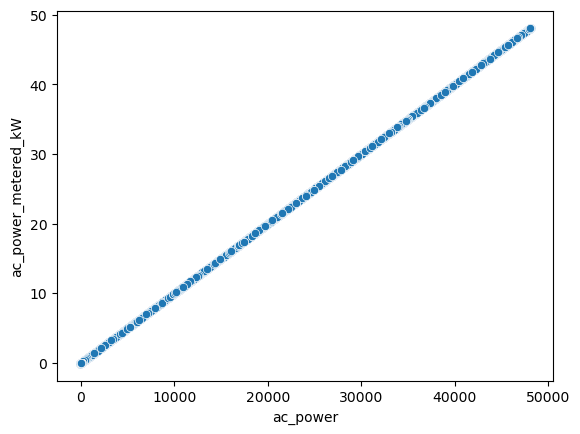

In [139]:
sns.scatterplot(
    data = wide_1200,
    x = 'ac_power',
    y = 'ac_power_metered_kW'
)

In [140]:
wide_1200_missing = wide_1200.isna()
wide_1200_missing[['ac_power', 'ac_power_metered_kW']].value_counts()

ac_power  ac_power_metered_kW
False     False                  642632
True      False                  208019
          True                    92327
Name: count, dtype: int64

For System 1200, ac_power is ac_power_metered_W vs. kW!  Good to know.  (ac_power_metered_kW has less missingness)

In [28]:
ac_power_max = wide_1200['ac_power'].max()
wide_1200_trimmed = wide_1200[wide_1200['ac_power'] > 0.01 * ac_power_max]

In [32]:
wide_1200_trimmed.describe()

,measured_on,ac_power,inv1_ac_power,inv2_ac_power,inv3_ac_power,inv4_ac_power,inv5_ac_power,inv6_ac_power,ac_power_metered_kW,inv_ac_total
count,288406,288406.000000,0.0,0.0,0.0,0.0,0.0,0.0,288406.000000,0.0
mean,2015-12-28 07:06:55.740337920,15629.512188,NaN,NaN,NaN,NaN,NaN,NaN,15.629512,NaN
min,2013-11-30 07:24:00,500.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,NaN
25%,2014-10-28 09:24:45,3600.000000,NaN,NaN,NaN,NaN,NaN,NaN,3.600000,NaN
50%,2015-09-26 07:13:30,10800.000000,NaN,NaN,NaN,NaN,NaN,NaN,10.800000,NaN
75%,2017-02-18 14:23:45,27400.000000,NaN,NaN,NaN,NaN,NaN,NaN,27.400000,NaN
max,2018-08-03 17:45:00,48120.000000,NaN,NaN,NaN,NaN,NaN,NaN,48.120000,NaN
std,NaN,13603.552143,NaN,NaN,NaN,NaN,NaN,NaN,13.603552,NaN


In [39]:
exxes = wide_1200_all['ac_power'].values
eyyes = wide_1200_all['inv_ac_total'].values
eyyes

array([], dtype=float64)

In [40]:
exxes

array([], dtype=float64)

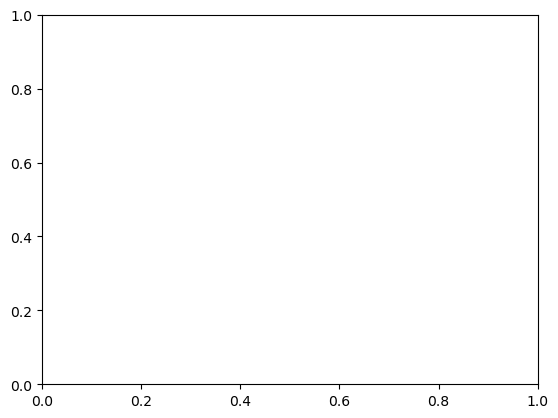

In [38]:
sns.scatterplot(
    x = wide_1200_all['ac_power'].values,
    y = wide_1200_all['inv_ac_total'].values
)
plt.show()

Not an error!  Never recorded at the same time!

### System 1202

In [74]:
system_id = 1202
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
103,1202,2810,inv1_ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,inv1_ac_power__2810
105,1202,2815,inv2_ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,inv2_ac_power__2815
107,1202,2820,inv3_ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,inv3_ac_power__2820
109,1202,2825,inv4_ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,inv4_ac_power__2825
111,1202,2830,inv5_ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,inv5_ac_power__2830
113,1202,2835,inv6_ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,inv6_ac_power__2835
115,1202,2840,ac_power,AC power,W,W,1.0,0.0,inv1_ac_power+inv2_ac_power+inv3_ac_power+inv4...,avg,NaN,NaN,,ac_power__2840
124,1202,2802,ac_power_metered_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_power_metered_kw__2802
141,1202,2805,power_factor,AC other,-,-,1.0,0.0,,NaN,NaN,NaN,,power_factor__2805


In [ ]:
path_1202 = Path(f'../../../../data_ds_project/systems/parquet/1202/')
pq_1202 = pq.ParquetDataset(
    path_1202, filters=[
            ('metric_id', 'in', [2810, 2815, 2820, 2825, 2830, 2835, 2840, 2802])
    ]
)
df_1202 = pq_1202.read().to_pandas()
df_1202 = df_1202.drop_duplicates()
df_1202.tail()

,measured_on,utc_measured_on,metric_id,value
2931682,2020-07-26 15:35:00,2020-07-26 19:35:00,2802,35280.0
2931683,2020-07-26 15:55:00,2020-07-26 19:55:00,2802,30720.0
2931684,2020-07-26 16:15:00,2020-07-26 20:15:00,2802,29840.0
2931685,2020-07-26 16:35:00,2020-07-26 20:35:00,2802,25280.0
2931686,2020-07-26 16:55:00,2020-07-26 20:55:00,2802,11200.0


In [91]:
df_1202[['measured_on', 'metric_id']].value_counts()

measured_on          metric_id
2018-08-04 16:05:00  2802         2
2018-11-04 01:10:00  2802         2
2018-11-04 01:30:00  2802         2
2018-11-04 01:50:00  2802         2
2018-11-04 01:00:00  2802         2
                                 ..
2020-07-26 15:35:00  2802         1
2020-07-26 15:55:00  2802         1
2020-07-26 16:15:00  2802         1
2020-07-26 16:35:00  2802         1
2020-07-26 16:55:00  2802         1
Name: count, Length: 2931662, dtype: int64

In [92]:
df_1202.loc[:, 'val_min'] = df_1202.groupby(['measured_on', 'metric_id'])['value'].transform('min')
df_1202.loc[:, 'val_max'] = df_1202.groupby(['measured_on', 'metric_id'])['value'].transform('max')
df_1202.loc[:, 'val_spread'] = df_1202['val_max'] - df_1202['val_min']
df_1202[df_1202['val_spread'] > 0.5]

,measured_on,utc_measured_on,metric_id,value,val_min,val_max,val_spread
2692770,2018-08-04 16:05:00,2018-08-04 20:05:00,2802,30680.00,30.68,30680.0,30649.32
2692830,2018-08-04 16:05:00,NaT,2802,30.68,30.68,30680.0,30649.32


Same issue!

In [93]:
df_1202 = df_1202.drop(columns='utc_measured_on')
df_1202.loc[:, 'mean_value'] = df_1202.groupby(['measured_on', 'metric_id'])['value'].transform('mean')
df_1202 = df_1202.drop(columns='value')
df_1202 = df_1202.rename(columns={'mean_value': 'value'})
df_1202 = df_1202.drop_duplicates()

In [94]:
wide_1202 = df_1202.pivot(
    index='measured_on',
    columns='metric_id',
    values='value'
)
wide_1202.columns.name = ''
wide_1202 = wide_1202.reset_index()
rename_cols = dict()
for ind in relevant_rows_metrics.index:
    rename_cols[relevant_rows_metrics.loc[ind, 'metric_id']] = relevant_rows_metrics.loc[ind, 'sensor_name']
wide_1202 = wide_1202.rename(columns=rename_cols)
wide_1202.head()

,measured_on,ac_power_metered_kW,inv1_ac_power,inv2_ac_power,inv3_ac_power,inv4_ac_power,inv5_ac_power,inv6_ac_power,ac_power
0,2010-12-29 14:30:03,NaN,1961.8824,2575.1176,1692.0000,2541.7059,2566.7647,2693.9412,14031.4118
1,2010-12-29 15:00:03,NaN,512.8889,597.0526,375.4737,983.5263,604.6316,915.0000,3988.5731
2,2010-12-29 15:15:03,NaN,406.1579,481.5789,302.8421,650.8947,490.5789,916.8421,3248.8946
3,2010-12-29 15:30:03,NaN,317.7895,370.8421,234.6842,493.3500,387.3500,703.7895,2507.8053
4,2010-12-29 15:45:03,NaN,258.6500,301.1500,188.8500,311.0000,312.2500,538.0000,1909.9000


In [95]:
wide_1202.count()


measured_on            1357319
ac_power_metered_kW    1351828
inv1_ac_power           226389
inv2_ac_power           226275
inv3_ac_power           226133
inv4_ac_power           226066
inv5_ac_power           226175
inv6_ac_power           226546
ac_power                222250
dtype: int64

Same issue!

In [96]:
df_inv1 = wide_1202.dropna(axis=0, subset=['inv1_ac_power'])
df_inv1.head(10)

,measured_on,ac_power_metered_kW,inv1_ac_power,inv2_ac_power,inv3_ac_power,inv4_ac_power,inv5_ac_power,inv6_ac_power,ac_power
0,2010-12-29 14:30:03,NaN,1961.8824,2575.1176,1692.0000,2541.7059,2566.7647,2693.9412,14031.4118
1,2010-12-29 15:00:03,NaN,512.8889,597.0526,375.4737,983.5263,604.6316,915.0000,3988.5731
2,2010-12-29 15:15:03,NaN,406.1579,481.5789,302.8421,650.8947,490.5789,916.8421,3248.8946
3,2010-12-29 15:30:03,NaN,317.7895,370.8421,234.6842,493.3500,387.3500,703.7895,2507.8053
4,2010-12-29 15:45:03,NaN,258.6500,301.1500,188.8500,311.0000,312.2500,538.0000,1909.9000
5,2010-12-29 16:00:03,NaN,193.5500,229.2000,140.0500,230.7619,239.4286,368.9048,1401.8953
6,2010-12-29 16:15:03,NaN,123.6000,147.2857,89.2857,147.4500,154.5238,206.7000,868.8452
7,2010-12-29 16:30:03,NaN,48.3000,61.1429,28.6190,64.6500,57.9000,67.0500,327.6619
8,2010-12-29 16:45:03,NaN,0.0000,0.0000,0.0000,1.8000,0.4500,0.3500,2.6000
9,2010-12-29 17:00:03,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [98]:
df_ac_pow = wide_1202.dropna(axis=0, subset=['ac_power_metered_kW'])
df_ac_pow.head(10)

,measured_on,ac_power_metered_kW,inv1_ac_power,inv2_ac_power,inv3_ac_power,inv4_ac_power,inv5_ac_power,inv6_ac_power,ac_power
235,2011-01-04 13:31:00,26.80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
238,2011-01-04 14:15:00,27.28,2436.0500,3343.4000,3369.5263,3214.60,3352.9000,3238.2000,18954.6763
239,2011-01-04 14:30:00,26.72,1794.9000,2488.3000,2503.5000,2540.60,2497.8421,2606.6500,14431.7921
240,2011-01-04 14:31:58,26.80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
241,2011-01-04 14:45:00,27.68,899.1429,1458.4000,1410.1500,1425.10,1454.4500,1834.8571,8482.1000
242,2011-01-04 14:52:03,25.64,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243,2011-01-04 14:54:00,24.80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
244,2011-01-04 14:55:00,24.44,677.6667,766.2857,724.5714,1326.75,766.1000,1289.3000,5550.6738
245,2011-01-04 14:56:00,24.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
246,2011-01-04 14:57:00,24.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [86]:
df_ac_all = wide_1202.dropna()
df_ac_all.shape

(220055, 8)

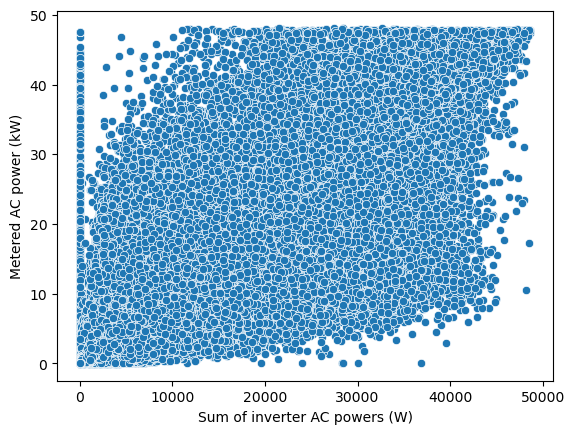

In [101]:
sns.scatterplot(
    data=wide_1202,
    x = 'ac_power',
    y = 'ac_power_metered_kW'
)
plt.xlabel('Sum of inverter AC powers (W)')
plt.ylabel('Metered AC power (kW)')
plt.show()

*Very* loosely correlated, though not the same missigness as before!

### System 1208

In [81]:
system_id = 1208
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
ac_power_metrics = metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')
ac_non_powerfactor_metrics = ac_power_metrics[ac_power_metrics['units'].isin(['W','kW'])]
ac_non_powerfactor_metrics

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
227,1208,1133,ac_power_metered_1_2,AC power,W,W,1.0,0.0,ac_meter_1_power_kW+ac_meter_2_power_kW,avg,NaN,NaN,,ac_power_metered_1_2__1133
230,1208,1016,ac_power_metered_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_power_metered_kw__1016
231,1208,1017,ac_meter_1_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_meter_1_power_kw__1017
232,1208,1018,ac_meter_2_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_meter_2_power_kw__1018
233,1208,1019,inv1_ac_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,inv1_ac_power_kw__1019
234,1208,1023,inv2_ac_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,inv2_ac_power_kw__1023


In [82]:
path_1208 = Path(f'../../../../data_ds_project/systems/parquet/1208/')
pq_1208 = pq.ParquetDataset(
    path_1208, filters=[
            ('metric_id', 'in', [1016,1017,1018,1019,1023,1133])
    ]
)
df_1208 = pq_1208.read().to_pandas()
df_1208 = df_1208.drop_duplicates()
df_1208.tail()

,measured_on,utc_measured_on,metric_id,value
108905672,2022-02-08 18:29:45,2022-02-09 01:29:45,1023,18728.69
108905673,2022-02-08 18:30:00,2022-02-09 01:30:00,1019,23971.54
108905674,2022-02-08 18:30:00,2022-02-09 01:30:00,1023,18542.90
108905675,2022-02-08 18:29:45,2022-02-09 01:29:45,1017,18748.36
108905676,2022-02-08 18:30:00,2022-02-09 01:30:00,1017,18748.36


In [83]:
df_1208 = df_1208.drop(columns='utc_measured_on')
df_1208 = df_1208.drop_duplicates()
df_1208[['measured_on', 'metric_id']].value_counts()

measured_on          metric_id
2018-02-20 10:20:00  1018         2
                     1016         2
                     1133         2
2018-02-20 10:20:15  1019         2
                     1018         2
                                 ..
2022-02-08 18:29:45  1023         1
2022-02-08 18:30:00  1019         1
                     1023         1
2022-02-08 18:29:45  1017         1
2022-02-08 18:30:00  1017         1
Name: count, Length: 108773113, dtype: int64

In [84]:
df_1208.loc[:, 'mean_value'] = df_1208.groupby(['measured_on', 'metric_id'])['value'].transform('mean')
df_1208 = df_1208.drop(columns='value')
df_1208 = df_1208.rename(columns = {'mean_value': 'value'})
df_1208 = df_1208.drop_duplicates()

In [85]:
wide_1208 = df_1208.pivot(
    index='measured_on',
    columns='metric_id',
    values='value'
)
wide_1208.columns.name = ''
wide_1208 = wide_1208.reset_index()
rename_cols = dict()
for ind in relevant_rows_metrics.index:
    rename_cols[relevant_rows_metrics.loc[ind, 'metric_id']] = relevant_rows_metrics.loc[ind, 'sensor_name']
wide_1208 = wide_1208.rename(columns=rename_cols)
wide_1208.head()

,measured_on,ac_power_metered_kW,ac_meter_1_power_kW,ac_meter_2_power_kW,inv1_ac_power_kW,inv2_ac_power_kW,ac_power_metered_1_2
0,2011-07-26 15:14:30,392.5,204.2890,203.4521,188.8734,201.2002,407741.1
1,2011-07-26 15:14:45,176.4,97.6406,120.2521,146.0400,197.2868,217892.7
2,2011-07-26 15:15:00,396.9,182.7988,170.8319,157.7534,134.9067,353630.7
3,2011-07-26 15:15:15,399.1,199.2969,198.7268,196.3067,147.7600,398023.7
4,2011-07-26 15:15:30,396.1,197.7001,197.4632,199.3201,201.8000,395163.3


Note: clearly ac_power_metered_1_2 is in W and ac_power_metered_kW is in kW.

In [86]:
wide_1208.count()


measured_on             19760460
ac_power_metered_kW     19342111
ac_meter_1_power_kW     19335204
ac_meter_2_power_kW     16445331
inv1_ac_power_kW        19384593
inv2_ac_power_kW        17669914
ac_power_metered_1_2    16595960
dtype: int64

In [89]:
wide_1208_emptiness = wide_1208.isna()
wide_1208_emptiness[['ac_power_metered_kW', 'ac_power_metered_1_2']].value_counts()

ac_power_metered_kW  ac_power_metered_1_2
False                False                   16213162
                     True                     3128949
True                 False                     382798
                     True                       35551
Name: count, dtype: int64

In [90]:
# ac_power_metered_kW has less missingness, but it's not uniform.

### System 1283

In [27]:
system_id = 1283
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
505,1283,1137,ac_power,AC power,W,W,1.0,0.0,ac_meter_1_power_kW+ac_meter_2_power_kW,avg,NaN,NaN,,ac_power__1137
508,1283,1040,ac_power_metered_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_power_metered_kw__1040
509,1283,1041,ac_meter_1_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_meter_1_power_kw__1041
510,1283,1042,ac_meter_2_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_meter_2_power_kw__1042
511,1283,1043,inv1_ac_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,inv1_ac_power_kw__1043
512,1283,1047,inv2_ac_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,inv2_ac_power_kw__1047


In [28]:
relevant_rows_metrics

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
502,1283,1134,inv1_dc_power,DC power,W,W,1.0,0.0,inv1_dc_voltage*inv1_dc_current,avg,NaN,NaN,,inv1_dc_power__1134
503,1283,1135,inv2_dc_power,DC power,W,W,1.0,0.0,inv2_dc_voltage*inv2_dc_current,avg,NaN,NaN,,inv2_dc_power__1135
504,1283,1136,dc_power,DC power,W,W,1.0,0.0,inv1_dc_power+inv2_dc_power,avg,NaN,NaN,,dc_power__1136
505,1283,1137,ac_power,AC power,W,W,1.0,0.0,ac_meter_1_power_kW+ac_meter_2_power_kW,avg,NaN,NaN,,ac_power__1137
506,1283,1045,inv1_dc_current,DC current,A,A,1.0,0.0,,avg,NaN,NaN,,inv1_dc_current__1045
507,1283,1049,inv2_dc_current,DC current,A,A,1.0,0.0,,avg,NaN,NaN,,inv2_dc_current__1049
508,1283,1040,ac_power_metered_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_power_metered_kw__1040
509,1283,1041,ac_meter_1_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_meter_1_power_kw__1041
510,1283,1042,ac_meter_2_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,ac_meter_2_power_kw__1042
511,1283,1043,inv1_ac_power_kW,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,inv1_ac_power_kw__1043


In [29]:
path_1283 = Path(f'../../../../data_ds_project/systems/parquet/1283/')
pq_1283 = pq.ParquetDataset(
    path_1283, filters=[
            ('metric_id', 'in', [1040, 1041, 1042, 1043, 1047, 1137, 1045, 1134, 1135, 1136])
    ]
)
df_1283 = pq_1283.read().to_pandas()
df_1283 = df_1283.drop_duplicates()
df_1283.tail()

,measured_on,utc_measured_on,metric_id,value
167299540,2022-02-08 18:36:30,2022-02-09 01:36:30,1135,23091.3712
167299541,2022-02-08 18:36:45,2022-02-09 01:36:45,1042,16972.1100
167299542,2022-02-08 18:36:45,2022-02-09 01:36:45,1135,22906.8921
167299543,2022-02-08 18:37:00,2022-02-09 01:37:00,1042,16813.7700
167299544,2022-02-08 18:37:00,2022-02-09 01:37:00,1135,22862.8058


In [32]:
df_1283[['measured_on', 'metric_id']].value_counts()

measured_on          metric_id
2020-07-16 11:51:30  1137         2
2020-07-16 11:51:45  1047         2
2020-07-16 11:52:45  1047         2
2020-07-16 11:53:30  1047         2
2020-07-16 11:58:15  1047         2
                                 ..
2022-02-08 18:36:30  1135         1
2022-02-08 18:36:45  1042         1
                     1135         1
2022-02-08 18:37:00  1042         1
                     1135         1
Name: count, Length: 167012985, dtype: int64

In [30]:
df_1283 = df_1283.drop(columns='utc_measured_on')
df_1283 = df_1283.drop_duplicates()

In [31]:
df_1283[['measured_on', 'metric_id']].value_counts()

measured_on          metric_id
2020-07-16 11:51:30  1137         2
2020-07-16 11:51:45  1047         2
2020-07-16 11:52:45  1047         2
2020-07-16 11:53:30  1047         2
2020-07-16 11:58:15  1047         2
                                 ..
2022-02-08 18:36:30  1135         1
2022-02-08 18:36:45  1042         1
                     1135         1
2022-02-08 18:37:00  1042         1
                     1135         1
Name: count, Length: 167012985, dtype: int64

In [ ]:
df_1283[df_1283['measured_on'] == '2020-07-16 11:51:30']

,measured_on,metric_id,value
83402908,2020-07-16 11:51:30,1043,0.0000
83402909,2020-07-16 11:51:30,1040,134600.0000
83402910,2020-07-16 11:51:30,1047,67633.4800
83402911,2020-07-16 11:51:30,1137,134.7665
83411135,2020-07-16 11:51:30,1041,66878.4800
83422367,2020-07-16 11:51:30,1042,67887.9700
83422370,2020-07-16 11:51:30,1137,134.7664
83430593,2020-07-16 11:51:30,1041,66878.4800


In [33]:
df_1283.loc[:, 'mean_value'] = df_1283.groupby(['measured_on', 'metric_id']).transform('mean')
df_1283 = df_1283.drop(columns='value')
df_1283 = df_1283.rename(columns={'mean_value': 'value'})
df_1283 = df_1283.drop_duplicates()

In [34]:
wide_1283 = df_1283.pivot(
    index='measured_on',
    columns='metric_id',
    values='value'
)
wide_1283.columns.name = ''
wide_1283 = wide_1283.reset_index()
rename_cols = dict()
for ind in relevant_rows_metrics.index:
    rename_cols[relevant_rows_metrics.loc[ind, 'metric_id']] = relevant_rows_metrics.loc[ind, 'sensor_name']
wide_1283 = wide_1283.rename(columns=rename_cols)
wide_1283.head()

,measured_on,ac_power_metered_kW,ac_meter_1_power_kW,ac_meter_2_power_kW,inv1_ac_power_kW,inv1_dc_current,inv2_ac_power_kW,inv1_dc_power,inv2_dc_power,dc_power,ac_power
0,2012-01-09 17:00:45,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2012-01-09 17:01:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2012-01-09 17:01:15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2012-01-09 17:01:30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2012-01-09 17:01:45,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [35]:
wide_1283.loc[:, 'ac_inv_power_sum'] = wide_1283['inv1_ac_power_kW'] + wide_1283['inv2_ac_power_kW']

In [40]:
wide_1283.describe()

,measured_on,ac_power_metered_kW,ac_meter_1_power_kW,ac_meter_2_power_kW,inv1_ac_power_kW,inv1_dc_current,inv2_ac_power_kW,inv1_dc_power,inv2_dc_power,dc_power,ac_power,ac_inv_power_sum
count,17588429,1.757258e+07,1.661205e+07,1.710786e+07,17557528.0,1.758735e+07,1.755577e+07,1.758535e+07,1.758530e+07,1.161351e+07,1.623569e+07,1.755564e+07
mean,2017-01-20 05:49:27.030303232,2.167737e+04,9.007547e+03,1.144449e+04,0.0,-1.356715e+01,1.110394e+04,1.085359e+05,1.498444e+05,3.729155e+05,4.339352e+04,1.110397e+04
min,2012-01-09 17:00:45,-9.000000e+02,0.000000e+00,0.000000e+00,0.0,-7.999000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-7.999000e+06,0.000000e+00
25%,2014-02-26 07:20:45,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2017-03-26 08:08:30,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2019-12-16 08:26:15,2.059000e+02,8.265254e+01,1.041888e+02,0.0,0.000000e+00,1.020602e+02,0.000000e+00,5.488920e+04,5.365824e+04,2.453342e+04,1.020667e+02
max,2022-02-08 18:37:00,5.008000e+05,2.514649e+05,2.518420e+05,0.0,0.000000e+00,2.501001e+05,6.398400e+07,6.398400e+07,1.279680e+08,5.024868e+05,2.501001e+05
std,NaN,6.660460e+04,3.078359e+04,3.432485e+04,0.0,3.291497e+02,3.376001e+04,2.633018e+06,2.706288e+06,6.515954e+06,1.229773e+05,3.376008e+04


In [43]:
wide_1283['dc_power'].value_counts()

dc_power
0.000000e+00    6493760
1.279680e+08      29728
6.398400e+07       1810
6.026088e+03         17
5.893598e+03         13
                 ...   
5.880965e+03          1
5.848923e+03          1
3.112054e+03          1
3.409330e+03          1
3.011885e+03          1
Name: count, Length: 5061968, dtype: int64

In [ ]:
wide_1283_ac_power_max = wide_1283['ac_power'].max()
wide_1283_ac_power_metered_max = wide_1283['ac_power_metered_kW'].max()
wide_1283_ac_power_inv_max = wide_1283['ac_inv_power_sum'].max()

In [ ]:
wide_1283_trimmed = wide_1283[(wide_1283['ac_power'] > 0.01 * wide_1283_ac_power_max)
                              & (wide_1283['ac_power_metered_kW'] > 0.01 * wide_1283_ac_power_metered_max)
                              & (wide_1283['ac_inv_power_sum'] > 0.01 * wide_1283_ac_power_inv_max)]

In [46]:
wide_1283_trimmed.loc[:, 'double_dc_power_trimmed'] = wide_1283_trimmed['dc_power'].clip(upper = 3e5) * 2

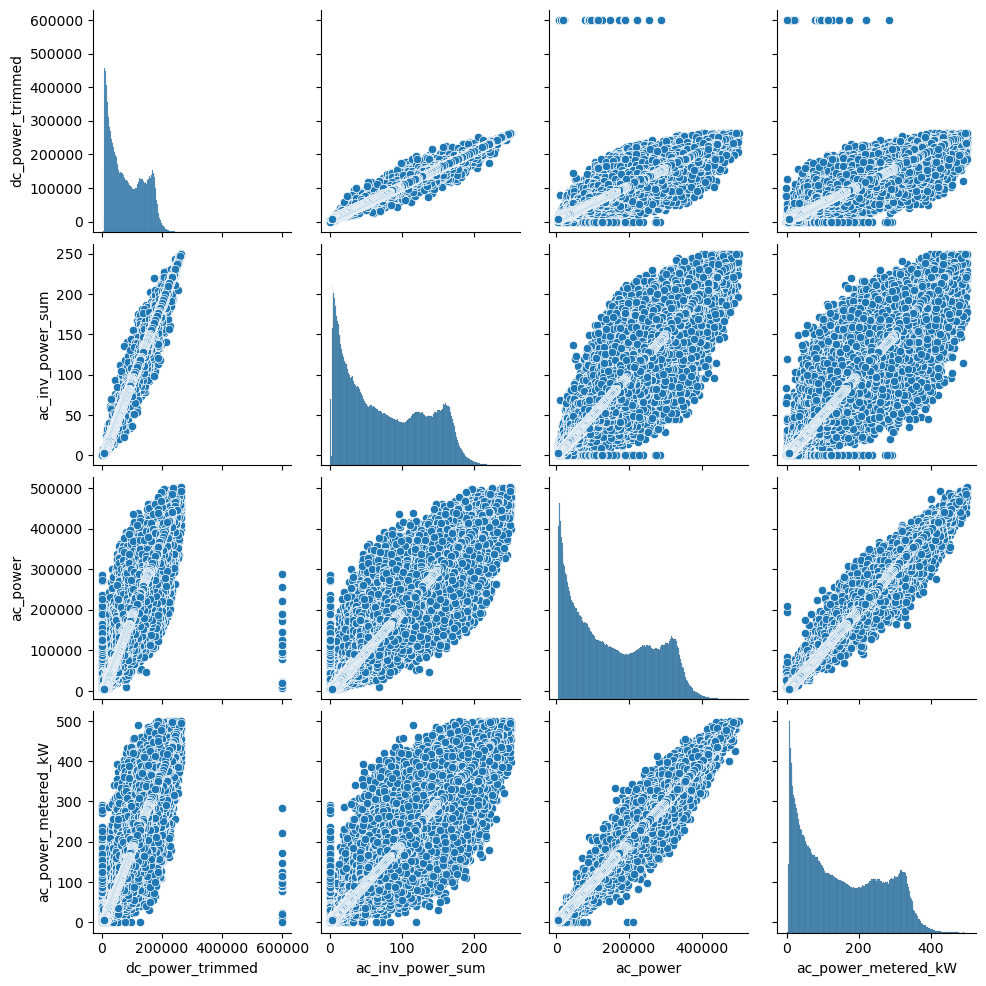

In [45]:
sns.pairplot(
    data = wide_1283_trimmed,
    vars = ['dc_power_trimmed', 'ac_inv_power_sum', 'ac_power', 'ac_power_metered_kW']
)
plt.show()

<Axes: xlabel='double_dc_power_trimmed', ylabel='ac_inv_power_sum'>

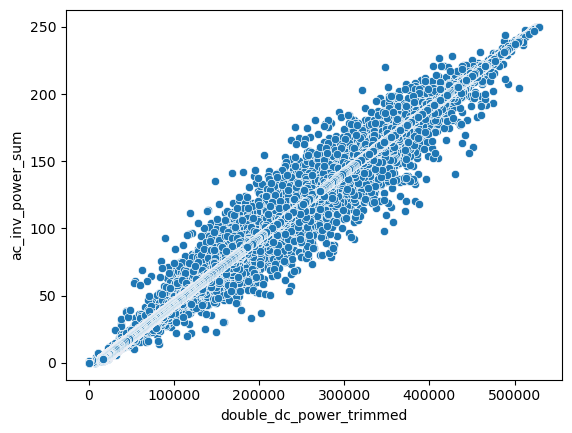

In [48]:
sns.scatterplot(
    data = wide_1283_trimmed,
    x = 'double_dc_power_trimmed',
    y = 'ac_inv_power_sum'
)

OK, so a times-2 factor to dc_power normalizes things.

<Axes: xlabel='ac_power', ylabel='inv_power_sum'>

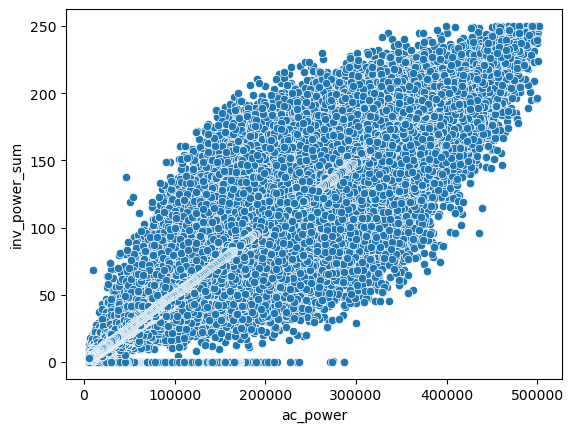

In [47]:
sns.scatterplot(
    data = wide_1283_trimmed,
    x = 'ac_power',
    y = 'inv_power_sum'
)

So all 3 of the terms are very well-behaved, but nothing is obviously right.
$P = I \cdot V$ as tiebreaker?
Well, no.  That only has DC data, and that gives the DC power that is 1/2 of the AC power, roughly.

### System 1332

In [103]:
system_id = 1332
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
864,1332,2641,meter3_ac_power,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,meter3_ac_power__2641
865,1332,2640,meter2_ac_power,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,meter2_ac_power__2640
869,1332,2642,inv1_ac_power,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,inv1_ac_power__2642
870,1332,2646,inv2_ac_power,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,inv2_ac_power__2646
871,1332,2650,inv3_ac_power,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,inv3_ac_power__2650
872,1332,2639,meter1_ac_power,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,meter1_ac_power__2639
873,1332,2638,metered_ac_power,AC power,kW,W,1000.0,0.0,,avg,NaN,NaN,,metered_ac_power__2638
874,1332,2654,inv_total_ac_power,AC power,W,W,1.0,0.0,inv1_ac_power+inv2_ac_power+inv3_ac_power,avg,NaN,NaN,,inv_total_ac_power__2654


In [104]:
path_1332 = Path(f'../../../../data_ds_project/systems/parquet/1332/')
pq_1332 = pq.ParquetDataset(
    path_1332, filters=[
            ('metric_id', 'in', [2654, 2638])
    ]
)
df_1332 = pq_1332.read().to_pandas()
df_1332 = df_1332.drop_duplicates()
df_1332.tail()

,measured_on,utc_measured_on,metric_id,value
23863681,2022-01-18 11:32:15,2022-01-18 18:32:15,2638,43300.0
23863682,2022-01-18 11:33:15,2022-01-18 18:33:15,2638,43700.0
23863683,2022-01-18 11:31:30,2022-01-18 18:31:30,2638,43000.0
23863684,2022-01-18 11:32:30,2022-01-18 18:32:30,2638,43300.0
23863685,2022-01-18 11:33:30,2022-01-18 18:33:30,2638,43700.0


In [105]:
df_1332[['measured_on', 'metric_id']].value_counts()

measured_on          metric_id
2018-08-04 23:52:00  2638         2
2018-08-04 23:51:30  2638         2
2018-08-04 23:52:30  2638         2
2018-08-04 23:53:30  2638         2
2018-08-04 23:54:30  2638         2
                                 ..
2022-01-18 11:32:15  2638         1
2022-01-18 11:33:15  2638         1
2022-01-18 11:31:30  2638         1
2022-01-18 11:32:30  2638         1
2022-01-18 11:33:30  2638         1
Name: count, Length: 23826855, dtype: int64

In [108]:
df_1332.loc[:, 'measured_on'] = pd.to_datetime(df_1332.measured_on, format='%Y-%m-%d %H:%M:%S').astype('datetime64[s]')

In [109]:
df_1332.loc[:, 'val_min'] = df_1332.groupby(['measured_on', 'metric_id'])['value'].transform('min')
df_1332.loc[:, 'val_max'] = df_1332.groupby(['measured_on', 'metric_id'])['value'].transform('max')
df_1332.loc[:, 'val_spread'] = df_1332['val_max'] - df_1332['val_min']

In [110]:
df_1332_high_spread = df_1332.loc[df_1332['val_spread'] > 0.5]
df_1332_high_spread.loc[:, 'spread_date'] = df_1332_high_spread['measured_on'].dt.date
df_1332_high_spread['spread_date'].value_counts()

spread_date
2018-08-04    70
Name: count, dtype: int64

In [111]:
df_1332_high_spread['measured_on'].max() - df_1332_high_spread['measured_on'].min()

Timedelta('0 days 00:08:30')

High-spread occurrences isolated to 8.5 hours on Aug. 4, 2018 -- localized problem!  For exploration, just shift it!

In [113]:
df_1332.loc[:, 'mean_value'] = df_1332.groupby(['measured_on', 'metric_id'])['value'].transform('mean')
df_1332 = df_1332.drop(columns='value')
df_1332 = df_1332.rename(columns={'mean_value': 'value'})
df_1332 = df_1332.drop_duplicates()

In [114]:
df_1332[['measured_on', 'metric_id']].value_counts()

measured_on          metric_id
2013-03-29 12:02:15  2638         1
                     2654         1
2013-03-29 12:02:30  2638         1
2013-03-29 12:04:00  2638         1
                     2654         1
                                 ..
2022-01-18 11:32:15  2638         1
2022-01-18 11:33:15  2638         1
2022-01-18 11:31:30  2638         1
2022-01-18 11:32:30  2638         1
2022-01-18 11:33:30  2638         1
Name: count, Length: 23826855, dtype: int64

In [115]:
wide_1332 = df_1332.pivot(
    index='measured_on',
    columns='metric_id',
    values='value'
)
wide_1332.columns.name = ''
wide_1332 = wide_1332.reset_index()
rename_cols = dict()
for ind in relevant_rows_metrics.index:
    rename_cols[relevant_rows_metrics.loc[ind, 'metric_id']] = relevant_rows_metrics.loc[ind, 'sensor_name']
wide_1332 = wide_1332.rename(columns=rename_cols)
wide_1332.head()

,measured_on,metered_ac_power,inv_total_ac_power
0,2013-03-29 12:01:45,355.6,355600.0
1,2013-03-29 12:02:00,348.9,348900.0
2,2013-03-29 12:02:15,333.8,333800.0
3,2013-03-29 12:02:30,326.1,326100.0
4,2013-03-29 12:02:45,320.2,320200.0


In [116]:
wide_1332.count()


measured_on           17191082
metered_ac_power      17191073
inv_total_ac_power     6635782
dtype: int64

In [122]:
wide_1332.dropna(axis=0, subset=['metered_ac_power']).count()


measured_on           17191073
metered_ac_power      17191073
inv_total_ac_power     6635773
dtype: int64

In [123]:
wide_1332.dropna(axis=0, subset=['inv_total_ac_power']).count()


measured_on           6635782
metered_ac_power      6635773
inv_total_ac_power    6635782
dtype: int64

Only 9 times have missing metered_ac_power, but inv_total_ac_power shows up only about a 3rd of the time!

In [118]:
systems_cleaned[systems_cleaned['system_id'] == 1332]

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_ambient_temperature_data,has_temperature_data,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type,system_source
107,1332,NREL Parking Garage,"Golden, CO",7,39.7388,-105.1732,1770.0,1153.488,BSk,12,...,False,False,True,True,True,True,True,mono-Si,monocrystalline_Si,PVDAQ General
108,1332,NREL Parking Garage,"Golden, CO",7,39.7388,-105.1732,1770.0,1153.488,BSk,12,...,False,False,True,True,True,True,True,mono-Si,monocrystalline_Si,PVDAQ General


In [119]:
wide_1332_trimmed = wide_1332[
    (wide_1332['metered_ac_power'] > 0.5)
    & (wide_1332['metered_ac_power'] < 1153*2)
    & (wide_1332['inv_total_ac_power'] > 500)
    & (wide_1332['inv_total_ac_power'] < 1153 * 2000)
]

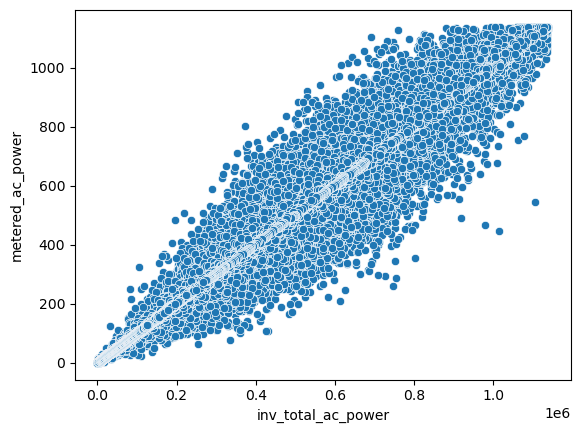

In [125]:
sns.scatterplot(
    data=wide_1332_trimmed,
    x = 'inv_total_ac_power',
    y = 'metered_ac_power'
)
plt.show()

Reasonably co-variant!

c:\Users\ch83b\anaconda3\envs\erdos_ds_environment\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


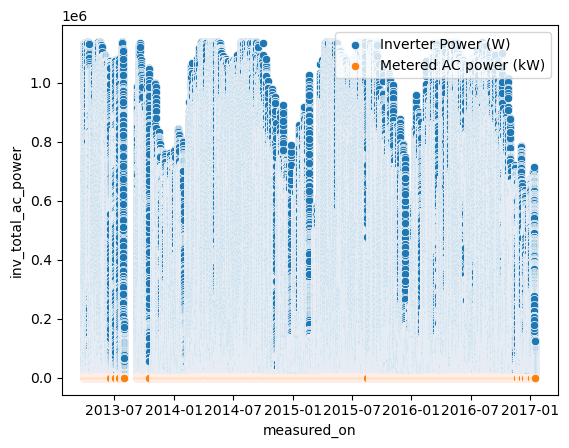

In [127]:
sns.scatterplot(
    data = wide_1332_trimmed,
    x = 'measured_on',
    y = 'inv_total_ac_power',
    label = 'Inverter Power (W)'
)
sns.scatterplot(
    data = wide_1332_trimmed,
    x = 'measured_on',
    y = 'metered_ac_power',
    label='Metered AC power (kW)'
)
plt.legend()
plt.show()

### System 1416

In [48]:
system_id = 1416
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
metrics_search_for_two_fragments_df(relevant_rows_metrics, 'pow', 'ac', 'and')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1112,1416,4746,power_factor,AC other,-,-,1.0,0.0,,avg,NaN,NaN,,power_factor__4746
1113,1416,4753,power_factor_phA,AC other,-,-,1.0,0.0,,avg,NaN,NaN,,power_factor_pha__4753
1114,1416,4754,power_factor_phB,AC other,-,-,1.0,0.0,,avg,NaN,NaN,,power_factor_phb__4754
1115,1416,4755,power_factor_phC,AC other,-,-,1.0,0.0,,avg,NaN,NaN,,power_factor_phc__4755
1116,1416,4745,apparent_power_kVA,AC other,kVA,VA,1000.0,0.0,,avg,NaN,NaN,,apparent_power_kva__4745
1117,1416,4744,reactive_power_kVAR,AC other,kVAR,VAR,1000.0,0.0,,avg,NaN,NaN,,reactive_power_kvar__4744
1135,1416,4743,real_power_kW,AC power other,kW,W,1000.0,0.0,,avg,NaN,NaN,,real_power_kw__4743
1136,1416,4750,real_power_phA_kW,AC power other,kW,W,1000.0,0.0,,avg,NaN,NaN,,real_power_pha_kw__4750
1137,1416,4751,real_power_phB_kW,AC power other,kW,W,1000.0,0.0,,avg,NaN,NaN,,real_power_phb_kw__4751
1138,1416,4752,real_power_phC_kW,AC power other,kW,W,1000.0,0.0,,avg,NaN,NaN,,real_power_phc_kw__4752


In [216]:
relevant_rows_metrics[relevant_rows_metrics['common_name'].str.contains('pow')]

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1107,1416,4742,dc_power,DC power,W,W,1.0,0.0,,avg,NaN,NaN,,dc_power__4742
1129,1416,4741,dc_power_negative,DC power,W,W,1.0,0.0,,avg,NaN,NaN,,dc_power_negative__4741
1130,1416,4738,dc_power_positive,DC power,W,W,1.0,0.0,,avg,NaN,NaN,,dc_power_positive__4738
1135,1416,4743,real_power_kW,AC power other,kW,W,1000.0,0.0,,avg,NaN,NaN,,real_power_kw__4743
1136,1416,4750,real_power_phA_kW,AC power other,kW,W,1000.0,0.0,,avg,NaN,NaN,,real_power_pha_kw__4750
1137,1416,4751,real_power_phB_kW,AC power other,kW,W,1000.0,0.0,,avg,NaN,NaN,,real_power_phb_kw__4751
1138,1416,4752,real_power_phC_kW,AC power other,kW,W,1000.0,0.0,,avg,NaN,NaN,,real_power_phc_kw__4752


In [207]:
path_1416= Path(f'../../../../data_ds_project/systems/parquet/1416/')
pq_1416 = pq.ParquetDataset(
    path_1416, filters=[
            ('metric_id', 'in', [4738, 4741, 4742])
    ]
)
df_1416 = pq_1416.read().to_pandas()
df_1416 = df_1416.drop_duplicates()
df_1416.tail()

,measured_on,utc_measured_on,metric_id,value
10525176,2018-03-26 22:50:25,NaT,4741,0.288871
10525177,2018-03-26 22:50:30,NaT,4738,0.140005
10525178,2018-03-26 22:50:30,NaT,4741,0.216653
10525179,2018-03-26 22:50:35,NaT,4738,0.123390
10525180,2018-03-26 22:50:35,NaT,4741,0.361088


In [209]:
df_1416_wide = df_1416.pivot(
    index='measured_on',
    columns = 'metric_id',
    values='value'
)
df_1416_wide.columns.name = ''
df_1416_wide = df_1416_wide.reset_index()
df_1416_wide = df_1416_wide.rename(columns={
    4738: 'dc_power_positive',
    4741: 'dc_power_negative',
    4742: 'dc_power'
})

In [211]:
df_1416_wide

,measured_on,dc_power_positive,dc_power_negative,dc_power
0,2015-11-05 16:33:10,10850.730000,10157.660000,21008.390000
1,2015-11-05 16:33:15,10896.620000,10038.930000,20935.550000
2,2015-11-05 16:33:20,10855.990000,9928.960000,20784.950000
3,2015-11-05 16:33:25,11105.000000,9872.675000,20977.680000
4,2015-11-05 16:33:30,10604.860000,9857.531000,20462.390000
...,...,...,...,...
3508389,2018-03-26 22:50:15,0.140005,-0.288871,-0.148866
3508390,2018-03-26 22:50:20,0.140005,-0.333397,-0.193393
3508391,2018-03-26 22:50:25,0.156619,0.288871,0.445490
3508392,2018-03-26 22:50:30,0.140005,0.216653,0.356658


In [219]:
df_1416_wide['manual_sum'] = df_1416_wide['dc_power_positive'] + df_1416_wide['dc_power_negative']
df_1416_wide['manual_diff'] = df_1416_wide['dc_power_positive'] - df_1416_wide['dc_power_negative']

In [220]:
df_1416_wide['dc_power_negative'].describe()

count    3.508394e+06
mean     1.796907e+04
std      4.455719e+04
min     -1.294736e+03
25%     -1.877968e+01
50%     -1.011047e+00
75%      1.768127e+03
max      2.769924e+05
Name: dc_power_negative, dtype: float64

In [222]:
df_1416_wide.sample(15)

,measured_on,dc_power_positive,dc_power_negative,dc_power,manual_sum,manual_diff
3041498,2016-08-19 14:13:35,547.877000,-686.246300,-138.369300,-138.369300,1234.123300
48446,2015-11-08 11:50:20,113277.400000,110765.800000,224043.300000,224043.200000,2511.600000
1775872,2016-02-20 06:07:50,1.120037,-0.669896,0.450141,0.450141,1.789933
3027683,2016-08-18 19:02:20,444.028500,-497.543900,-53.515440,-53.515400,941.572400
3507040,2016-09-15 12:48:50,622.384800,-728.614800,-106.230000,-106.230000,1350.999600
3369746,2016-09-07 14:07:40,662.747000,-607.650100,55.096920,55.096900,1270.397100
706587,2015-12-18 00:58:00,0.840028,-3.740252,-2.900225,-2.900224,4.580280
3237596,2016-08-30 22:35:10,0.189848,-0.199817,-0.009969,-0.009969,0.389665
904529,2015-12-29 11:53:10,52033.090000,54748.180000,106781.300000,106781.270000,-2715.090000
2751255,2016-04-20 03:25:40,1.400046,-2.264886,-0.864840,-0.864840,3.664932
